In [1]:
import warnings
from pathlib import Path
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.base import clone
from sklearn.model_selection import GroupShuffleSplit, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import mutual_info_regression

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
np.random.seed(42)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [2]:
# Step 1 - Load and merge LR/SR inventories across tiles, then enrich from combined inventories when available.
repo_root = Path(r"C:\Users\ahtrabelsi\Desktop\stage\s2-super-resolution")
dataset_dir = repo_root / "yellowness_dataset"

lr_files = sorted(Path(p) for p in glob.glob(str(dataset_dir / "**" / "lr_inventory*.csv"), recursive=True))
sr_files = sorted(Path(p) for p in glob.glob(str(dataset_dir / "**" / "sr_inventory*.csv"), recursive=True))
combined_files = sorted(dataset_dir.glob("**/observations_inventory*.csv"))

if not lr_files or not sr_files:
    raise FileNotFoundError("Missing LR/SR inventory CSV files in yellowness_dataset.")

def load_inventory(files, label):
    parts = []
    for file_path in files:
        tmp = pd.read_csv(file_path)
        tmp["source_inventory"] = label
        tmp["source_file"] = str(file_path.relative_to(repo_root))
        parts.append(tmp)
    return pd.concat(parts, ignore_index=True)

def keyset_fallback(df_a, df_b):
    candidates = [
        ["id_plot", "observation_date", "s2_acquisition_date"],
        ["id_plot", "observation_date"],
        ["id_plot", "s2_acquisition_date"],
        ["id_plot", "s2_date"],
        ["id_plot", "month", "day_of_year"],
    ]
    for keys in candidates:
        if all(k in df_a.columns and k in df_b.columns for k in keys):
            return keys
    common = [k for k in ["id_plot", "observation_date", "s2_acquisition_date", "s2_date"] if k in df_a.columns and k in df_b.columns]
    if not common:
        raise ValueError("No shared keys between CSVs for merge.")
    return common

def dedupe_by_best_keys(df):
    candidates = [
        ["id_plot", "observation_date", "s2_acquisition_date"],
        ["id_plot", "observation_date"],
        ["id_plot", "s2_acquisition_date"],
        ["id_plot", "s2_date"],
    ]
    for keys in candidates:
        if all(k in df.columns for k in keys):
            return df.drop_duplicates(subset=keys, keep="last")
    return df.drop_duplicates(keep="last")

lr_df = dedupe_by_best_keys(load_inventory(lr_files, "lr"))
sr_df = dedupe_by_best_keys(load_inventory(sr_files, "sr"))

join_keys = keyset_fallback(lr_df, sr_df)
df = pd.merge(lr_df, sr_df, on=join_keys, how="inner", suffixes=("_lrdup", "_srdup"))

if combined_files:
    combined_parts = [pd.read_csv(p) for p in combined_files]
    combined_df = dedupe_by_best_keys(pd.concat(combined_parts, ignore_index=True))
    enrich_keys = keyset_fallback(df, combined_df)
    new_cols = [c for c in combined_df.columns if c not in df.columns or c in enrich_keys]
    df = pd.merge(df, combined_df[new_cols], on=enrich_keys, how="left", suffixes=("", "_combineddup"))

drop_suffixes = ("_lrdup", "_srdup", "_combineddup")
df = df.drop(columns=[c for c in df.columns if c.endswith(drop_suffixes)], errors="ignore")
df = df.loc[:, ~df.columns.duplicated()].copy()

for date_col in ["observation_date", "s2_acquisition_date", "s2_date"]:
    if date_col in df.columns:
        df[date_col] = pd.to_datetime(df[date_col], errors="coerce")

print(f"LR files: {len(lr_files)}")
print(f"SR files: {len(sr_files)}")
print(f"Combined files: {len(combined_files)}")
print(f"Join keys used: {join_keys}")
print(f"Merged shape: {df.shape}")
display(df.head())

LR files: 1
SR files: 1
Combined files: 1
Join keys used: ['id_plot', 'observation_date', 's2_acquisition_date']
Merged shape: (425, 115)


,id_plot,observation_date,s2_acquisition_date,lr_image_path,lr_mask_path,lr_NDRE_mean,lr_NDRE_std,lr_NDYVI_mean,lr_NDYVI_std,lr_GCC_mean,...,parcel_area_ha,month,day_of_year,s2_date_difference_days,day_offset,yellowness,lr_patch,sr_patch,lr_mask,sr_mask
0,16575797,2020-06-08,2020-06-09,images_lr\lr_plot_16575797_obs_2020-06-08.tif,masks_lr\mask_lr_plot_16575797_static.tif,0.230113,0.095358,-0.059414,0.126788,0.359409,...,0.001986,6,161,1,1,0.0,images_lr\lr_plot_16575797_obs_2020-06-08.tif,images_sr\sr_plot_16575797_obs_2020-06-08.tif,masks_lr\mask_lr_plot_16575797_static.tif,masks_sr\mask_sr_plot_16575797_static.tif
1,16575797,2020-06-15,2020-06-14,images_lr\lr_plot_16575797_obs_2020-06-15.tif,masks_lr\mask_lr_plot_16575797_static.tif,0.252225,0.094446,-0.032131,0.126343,0.362927,...,0.001986,6,166,1,1,0.0,images_lr\lr_plot_16575797_obs_2020-06-15.tif,images_sr\sr_plot_16575797_obs_2020-06-15.tif,masks_lr\mask_lr_plot_16575797_static.tif,masks_sr\mask_sr_plot_16575797_static.tif
2,16575797,2020-06-22,2020-06-24,images_lr\lr_plot_16575797_obs_2020-06-22.tif,masks_lr\mask_lr_plot_16575797_static.tif,0.299800,0.098380,0.029258,0.132714,0.371741,...,0.001986,6,176,2,2,1.0,images_lr\lr_plot_16575797_obs_2020-06-22.tif,images_sr\sr_plot_16575797_obs_2020-06-22.tif,masks_lr\mask_lr_plot_16575797_static.tif,masks_sr\mask_sr_plot_16575797_static.tif
3,16575797,2020-07-06,2020-07-04,images_lr\lr_plot_16575797_obs_2020-07-06.tif,masks_lr\mask_lr_plot_16575797_static.tif,0.365589,0.090121,0.115880,0.126189,0.382710,...,0.001986,7,186,2,2,10.0,images_lr\lr_plot_16575797_obs_2020-07-06.tif,images_sr\sr_plot_16575797_obs_2020-07-06.tif,masks_lr\mask_lr_plot_16575797_static.tif,masks_sr\mask_sr_plot_16575797_static.tif
4,16575797,2020-07-13,2020-07-14,images_lr\lr_plot_16575797_obs_2020-07-13.tif,masks_lr\mask_lr_plot_16575797_static.tif,0.430086,0.087577,0.207789,0.126229,0.398360,...,0.001986,7,196,1,1,15.0,images_lr\lr_plot_16575797_obs_2020-07-13.tif,images_sr\sr_plot_16575797_obs_2020-07-13.tif,masks_lr\mask_lr_plot_16575797_static.tif,masks_sr\mask_sr_plot_16575797_static.tif


In [4]:
# Step 1.5 - Add custom Sentinel-2 spectral features using band_Bxx columns

def find_band_column(frame, prefix, band):
    """
    Find Sentinel-2 band columns using the dataset naming convention:
    lr_band_B02_mean, sr_band_B08_mean, lr_band_B8A_mean, etc.
    """
    band_aliases = {
        "B2": ["B02", "B2"],
        "B3": ["B03", "B3"],
        "B4": ["B04", "B4"],
        "B5": ["B05", "B5"],
        "B6": ["B06", "B6"],
        "B7": ["B07", "B7"],
        "B8": ["B08", "B8"],
        "B8A": ["B8A"],
    }

    aliases = band_aliases.get(band, [band])

    candidates = []

    for alias in aliases:
        candidates.extend([
            f"{prefix}_band_{alias}_mean",
            f"{prefix}_band_{alias}",
            f"{prefix}_{alias}_mean",
            f"{prefix}_{alias}",
            f"{prefix}{alias}_mean",
            f"{prefix}{alias}",
        ])

    # Exact match
    for column in candidates:
        if column in frame.columns:
            return column

    # Case-insensitive match
    lower_columns = {
        str(column).lower(): column
        for column in frame.columns
    }

    for column in candidates:
        if column.lower() in lower_columns:
            return lower_columns[column.lower()]

    return None


def safe_ratio(numerator, denominator):
    """Compute a ratio while avoiding division by zero."""
    denominator = denominator.replace(0, np.nan)
    return numerator / denominator


def add_custom_spectral_features(frame, prefix):
    """Create vegetation indices for LR or SR Sentinel-2 bands."""
    bands = {}
    resolved_columns = {}

    for band in ["B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A"]:
        column = find_band_column(frame, prefix, band)

        if column is not None:
            bands[band] = pd.to_numeric(
                frame[column],
                errors="coerce",
            )
            resolved_columns[band] = column

    created = {}

    # NDVI = (B8 - B4) / (B8 + B4)
    if all(band in bands for band in ["B8", "B4"]):
        created[f"calc_{prefix}_NDVI"] = safe_ratio(
            bands["B8"] - bands["B4"],
            bands["B8"] + bands["B4"],
        )

    # NDRE_B5 = (B8 - B5) / (B8 + B5)
    if all(band in bands for band in ["B8", "B5"]):
        created[f"calc_{prefix}_NDRE_B5"] = safe_ratio(
            bands["B8"] - bands["B5"],
            bands["B8"] + bands["B5"],
        )

    # NDRE_B6 = (B8 - B6) / (B8 + B6)
    if all(band in bands for band in ["B8", "B6"]):
        created[f"calc_{prefix}_NDRE_B6"] = safe_ratio(
            bands["B8"] - bands["B6"],
            bands["B8"] + bands["B6"],
        )

    # NDRE_B7 = (B8 - B7) / (B8 + B7)
    if all(band in bands for band in ["B8", "B7"]):
        created[f"calc_{prefix}_NDRE_B7"] = safe_ratio(
            bands["B8"] - bands["B7"],
            bands["B8"] + bands["B7"],
        )

    # NDRE_B8A_B5 = (B8A - B5) / (B8A + B5)
    if all(band in bands for band in ["B8A", "B5"]):
        created[f"calc_{prefix}_NDRE_B8A_B5"] = safe_ratio(
            bands["B8A"] - bands["B5"],
            bands["B8A"] + bands["B5"],
        )

    # OSAVI = (B8 - B4) / (B8 + B4 + 0.16)
    if all(band in bands for band in ["B8", "B4"]):
        created[f"calc_{prefix}_OSAVI"] = safe_ratio(
            bands["B8"] - bands["B4"],
            bands["B8"] + bands["B4"] + 0.16,
        )

    # GLI = (2B3 - B4 - B2) / (2B3 + B4 + B2)
    if all(band in bands for band in ["B2", "B3", "B4"]):
        created[f"calc_{prefix}_GLI"] = safe_ratio(
            2 * bands["B3"] - bands["B4"] - bands["B2"],
            2 * bands["B3"] + bands["B4"] + bands["B2"],
        )

    for column, values in created.items():
        frame[column] = values

    print(f"{prefix.upper()} resolved bands:")
    for band, column in resolved_columns.items():
        print(f"  {band}: {column}")

    return list(created.keys())


created_lr_features = add_custom_spectral_features(df, "lr")
created_sr_features = add_custom_spectral_features(df, "sr")

created_feature_columns = (
    created_lr_features
    + created_sr_features
)

print("\nCreated LR features:")
print(created_lr_features)

print("\nCreated SR features:")
print(created_sr_features)

if not created_feature_columns:
    raise ValueError(
        "No custom spectral features were created. "
        "Check the available columns with df.columns.tolist()."
    )

display(df[created_feature_columns].head())

print("\nUpdated dataframe shape:", df.shape)
print("\nNew dataframe columns:")
print(created_feature_columns)

LR resolved bands:
  B2: lr_band_B02_mean
  B3: lr_band_B03_mean
  B4: lr_band_B04_mean
  B5: lr_band_B05_mean
  B6: lr_band_B06_mean
  B7: lr_band_B07_mean
  B8: lr_band_B08_mean
  B8A: lr_band_B8A_mean
SR resolved bands:
  B2: sr_band_B02_mean
  B3: sr_band_B03_mean
  B4: sr_band_B04_mean
  B5: sr_band_B05_mean
  B6: sr_band_B06_mean
  B7: sr_band_B07_mean
  B8: sr_band_B08_mean
  B8A: sr_band_B8A_mean

Created LR features:
['calc_lr_NDVI', 'calc_lr_NDRE_B5', 'calc_lr_NDRE_B6', 'calc_lr_NDRE_B7', 'calc_lr_NDRE_B8A_B5', 'calc_lr_OSAVI', 'calc_lr_GLI']

Created SR features:
['calc_sr_NDVI', 'calc_sr_NDRE_B5', 'calc_sr_NDRE_B6', 'calc_sr_NDRE_B7', 'calc_sr_NDRE_B8A_B5', 'calc_sr_OSAVI', 'calc_sr_GLI']


,calc_lr_NDVI,calc_lr_NDRE_B5,calc_lr_NDRE_B6,calc_lr_NDRE_B7,calc_lr_NDRE_B8A_B5,calc_lr_OSAVI,calc_lr_GLI,calc_sr_NDVI,calc_sr_NDRE_B5,calc_sr_NDRE_B6,calc_sr_NDRE_B7,calc_sr_NDRE_B8A_B5,calc_sr_OSAVI,calc_sr_GLI
0,0.300923,0.217972,0.043149,0.010221,0.229965,0.244661,0.044520,0.301161,0.213527,0.043045,0.009081,0.227320,0.244842,0.044597
1,0.330354,0.240382,0.045531,0.010000,0.252794,0.267313,0.051891,0.330491,0.234660,0.044380,0.007795,0.250547,0.267412,0.051965
2,0.393916,0.288152,0.050369,0.009559,0.301299,0.315514,0.069601,0.393818,0.279596,0.047048,0.005274,0.299394,0.315427,0.069658
3,0.483836,0.357545,0.063192,0.011074,0.367951,0.387570,0.093108,0.483465,0.351277,0.061160,0.007961,0.367492,0.387267,0.093028
4,0.573595,0.425449,0.074794,0.012417,0.433472,0.459523,0.124150,0.572969,0.421950,0.073975,0.010247,0.435047,0.459019,0.123877



Updated dataframe shape: (425, 129)

New dataframe columns:
['calc_lr_NDVI', 'calc_lr_NDRE_B5', 'calc_lr_NDRE_B6', 'calc_lr_NDRE_B7', 'calc_lr_NDRE_B8A_B5', 'calc_lr_OSAVI', 'calc_lr_GLI', 'calc_sr_NDVI', 'calc_sr_NDRE_B5', 'calc_sr_NDRE_B6', 'calc_sr_NDRE_B7', 'calc_sr_NDRE_B8A_B5', 'calc_sr_OSAVI', 'calc_sr_GLI']


In [5]:
# Step 2 - Dataset overview
print("Rows:", len(df))
print("Columns:", df.shape[1])
print("Parcels:", df["id_plot"].nunique() if "id_plot" in df.columns else "N/A")

if "id_plot" in df.columns:
    obs_stats = df.groupby("id_plot").size().describe()
    print("\nObservations per parcel (describe):")
    display(obs_stats)

if "yellowness" in df.columns:
    print("\nTarget missing values:", int(df["yellowness"].isna().sum()))
    print("Target describe:")
    display(df["yellowness"].describe())

Rows: 425
Columns: 129
Parcels: 128

Observations per parcel (describe):


count    128.000000
mean       3.320312
std        3.269842
min        1.000000
25%        1.000000
50%        2.000000
75%        4.000000
max       14.000000
dtype: float64


Target missing values: 0
Target describe:


count    425.000000
mean      39.114871
std       38.625783
min        0.000000
25%        3.000000
50%       25.000000
75%       80.000000
max      100.000000
Name: yellowness, dtype: float64

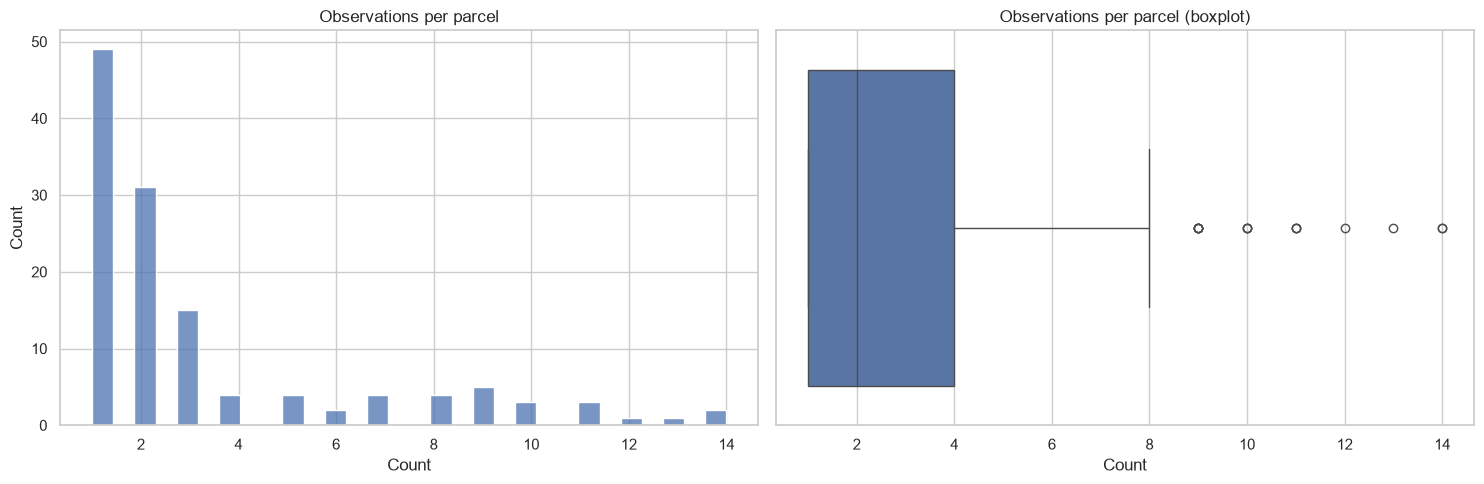

In [4]:
# Step 3 - Data exploration: observations per parcel
if "id_plot" not in df.columns:
    raise ValueError("id_plot column is required for grouped exploration.")

obs_per_parcel = df.groupby("id_plot").size()
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(obs_per_parcel, bins=30, ax=ax[0])
ax[0].set_title("Observations per parcel")
ax[0].set_xlabel("Count")

sns.boxplot(x=obs_per_parcel, ax=ax[1])
ax[1].set_title("Observations per parcel (boxplot)")
ax[1].set_xlabel("Count")

plt.tight_layout()
plt.show()

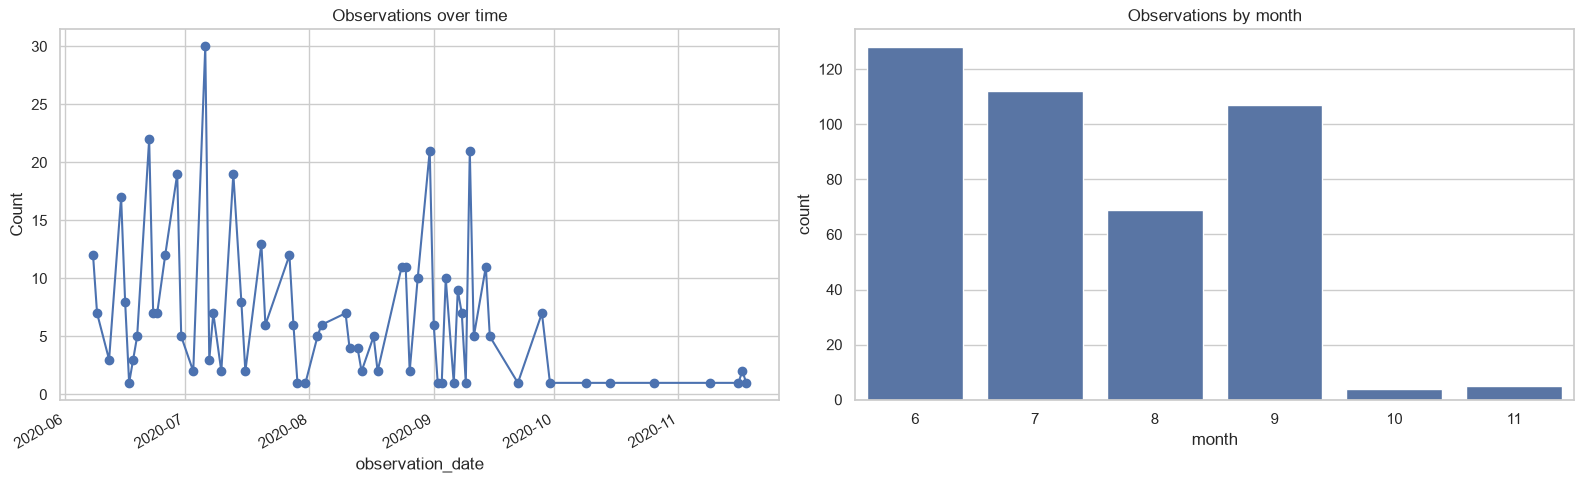

In [5]:
# Step 4 - Temporal exploration
date_col = "observation_date" if "observation_date" in df.columns else None
if date_col is None:
    raise ValueError("No observation_date column available for temporal plot.")

daily_counts = df.groupby(date_col).size().sort_index()

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
daily_counts.plot(marker="o", linewidth=1.5, ax=ax[0])
ax[0].set_title("Observations over time")
ax[0].set_ylabel("Count")

if "month" in df.columns:
    sns.countplot(data=df, x="month", order=sorted(df["month"].dropna().unique()), ax=ax[1])
    ax[1].set_title("Observations by month")
else:
    ax[1].text(0.5, 0.5, "month column unavailable", ha="center", va="center")
    ax[1].set_axis_off()

plt.tight_layout()
plt.show()

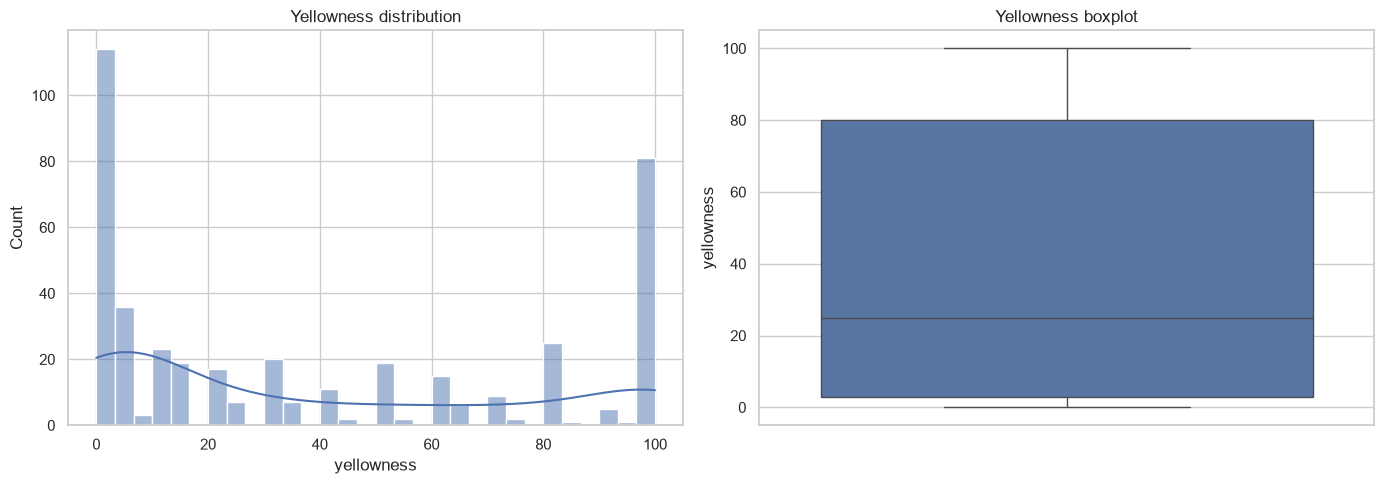

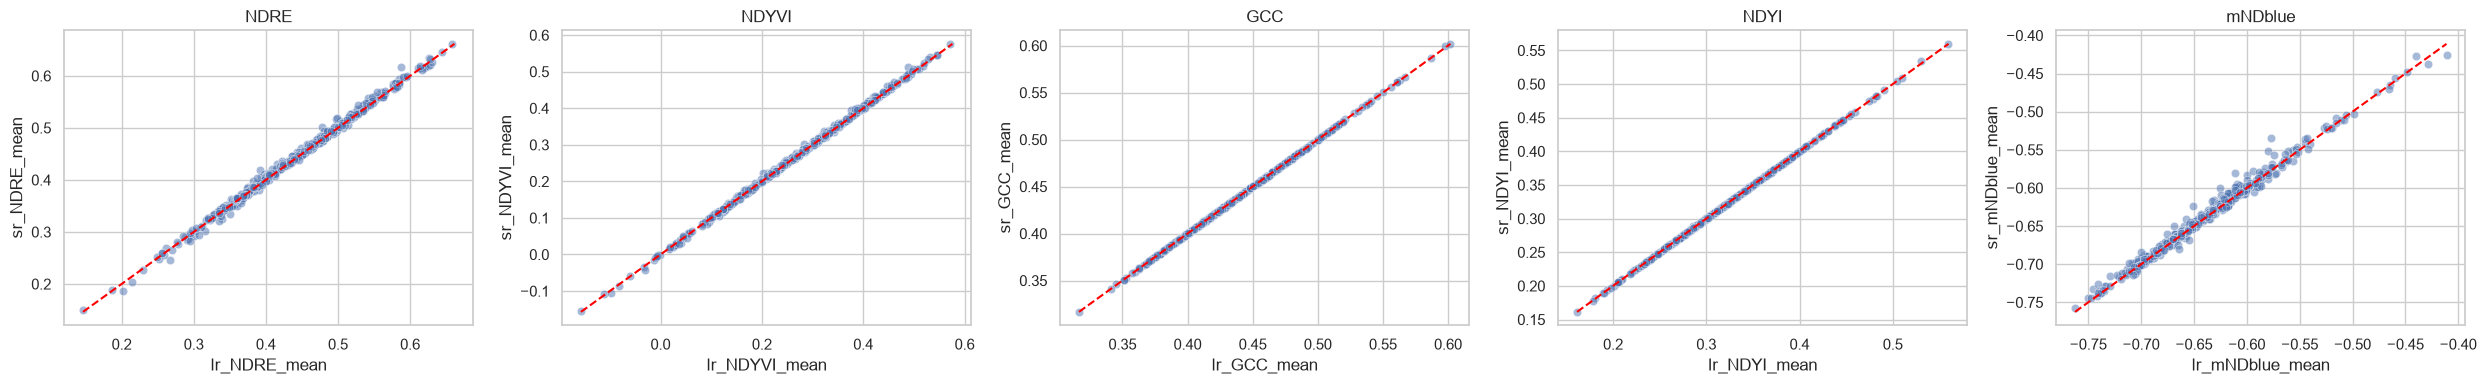

In [6]:
# Step 5 - Target distribution and LR/SR index agreement
if "yellowness" not in df.columns:
    raise ValueError("yellowness column is required.")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["yellowness"].dropna(), bins=30, kde=True, ax=ax[0])
ax[0].set_title("Yellowness distribution")

sns.boxplot(y=df["yellowness"], ax=ax[1])
ax[1].set_title("Yellowness boxplot")

plt.tight_layout()
plt.show()

indices = ["NDRE", "NDYVI", "GCC", "NDYI", "mNDblue"]
available_pairs = [(f"lr_{idx}_mean", f"sr_{idx}_mean", idx) for idx in indices if f"lr_{idx}_mean" in df.columns and f"sr_{idx}_mean" in df.columns]

if available_pairs:
    n = len(available_pairs)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, (lr_col, sr_col, label) in zip(axes, available_pairs):
        sns.scatterplot(data=df, x=lr_col, y=sr_col, alpha=0.5, ax=ax)
        lims = [
            np.nanmin([df[lr_col].min(), df[sr_col].min()]),
            np.nanmax([df[lr_col].max(), df[sr_col].max()]),
        ]
        ax.plot(lims, lims, color="red", linestyle="--")
        ax.set_title(label)
    plt.tight_layout()
    plt.show()

LR dataframe preview:


,year,parcel_area_m2,parcel_area_ha,month,day_of_year,s2_date_difference_days,id_plot,observation_date,s2_acquisition_date,day_offset,...,lr_RE_slope_740_783_mean,lr_RE_slope_740_783_std,lr_RE_slope_783_865_mean,lr_RE_slope_783_865_std,lr_RE_curvature_705_740_783_mean,lr_RE_curvature_705_740_783_std,lr_RE_curvature_740_783_865_mean,lr_RE_curvature_740_783_865_std,source_inventory,source_file
0,2020,19.86,0.001986,6,161,1,16575797,2020-06-08,2020-06-09,1,...,0.000658,0.000234,0.000253,0.000034,-0.096264,0.032330,-0.007550,0.011438,lr,yellowness_dataset\lr_inventory.csv
1,2020,19.86,0.001986,6,166,1,16575797,2020-06-15,2020-06-14,1,...,0.000706,0.000232,0.000256,0.000033,-0.105240,0.029586,-0.009345,0.011338,lr,yellowness_dataset\lr_inventory.csv
2,2020,19.86,0.001986,6,176,2,16575797,2020-06-22,2020-06-24,2,...,0.000803,0.000256,0.000264,0.000039,-0.123191,0.026614,-0.012933,0.012572,lr,yellowness_dataset\lr_inventory.csv
3,2020,19.86,0.001986,7,186,2,16575797,2020-07-06,2020-07-04,2,...,0.001078,0.000233,0.000269,0.000041,-0.148592,0.024719,-0.024280,0.012187,lr,yellowness_dataset\lr_inventory.csv
4,2020,19.86,0.001986,7,196,1,16575797,2020-07-13,2020-07-14,1,...,0.001352,0.000237,0.000275,0.000056,-0.173996,0.030236,-0.035625,0.013679,lr,yellowness_dataset\lr_inventory.csv


SR dataframe preview:


,year,parcel_area_m2,parcel_area_ha,month,day_of_year,s2_date_difference_days,id_plot,observation_date,s2_acquisition_date,day_offset,...,sr_RE_slope_740_783_mean,sr_RE_slope_740_783_std,sr_RE_slope_783_865_mean,sr_RE_slope_783_865_std,sr_RE_curvature_705_740_783_mean,sr_RE_curvature_705_740_783_std,sr_RE_curvature_740_783_865_mean,sr_RE_curvature_740_783_865_std,source_inventory,source_file
0,2020,19.86,0.001986,6,161,1,16575797,2020-06-08,2020-06-09,1,...,0.000679,0.000282,0.000262,0.000054,-0.092695,0.036289,-0.007747,0.010649,sr,yellowness_dataset\sr_inventory.csv
1,2020,19.86,0.001986,6,166,1,16575797,2020-06-15,2020-06-14,1,...,0.000730,0.000268,0.000274,0.000056,-0.101804,0.033181,-0.008894,0.010325,sr,yellowness_dataset\sr_inventory.csv
2,2020,19.86,0.001986,6,176,2,16575797,2020-06-22,2020-06-24,2,...,0.000828,0.000280,0.000299,0.000069,-0.120138,0.029412,-0.011088,0.011440,sr,yellowness_dataset\sr_inventory.csv
3,2020,19.86,0.001986,7,186,2,16575797,2020-07-06,2020-07-04,2,...,0.001105,0.000289,0.000313,0.000073,-0.145800,0.027693,-0.021850,0.013218,sr,yellowness_dataset\sr_inventory.csv
4,2020,19.86,0.001986,7,196,1,16575797,2020-07-13,2020-07-14,1,...,0.001385,0.000347,0.000327,0.000091,-0.171459,0.034081,-0.032738,0.017306,sr,yellowness_dataset\sr_inventory.csv


LR full pool: 55
SR full pool: 55


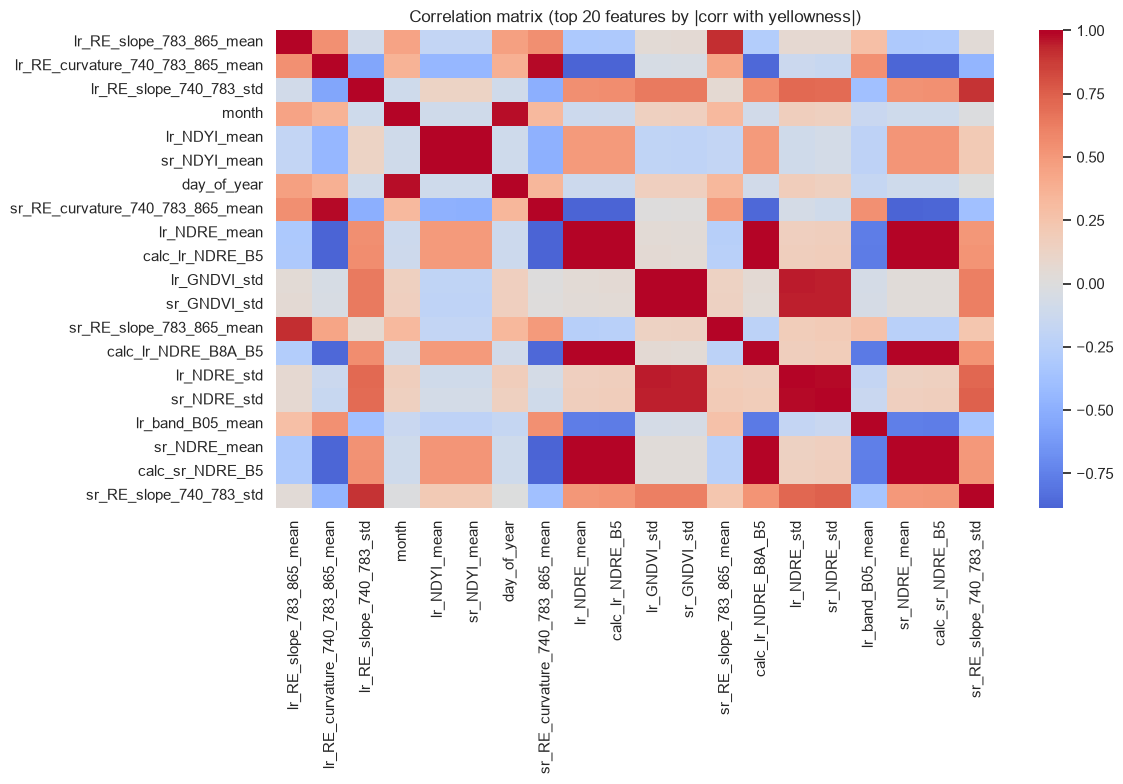

After collinearity filter:
LR decorrelated pool: 39
SR decorrelated pool: 39


In [6]:
# Step 6 - Feature pools, covariance, and collinearity filtering (LR and SR only)
target = "yellowness"

print("LR dataframe preview:")
display(lr_df.head())
print("SR dataframe preview:")
display(sr_df.head())

excluded_exact = {
    "year", "parcel_index", "id_plot", target, "source_file", "source_inventory"
}
excluded_keywords = (
    "patch", "mask", "observation_column", "stack_name", "observation_date", "s2_date",
    "valid_pixels", "valid_fill_ratio", "geometry_area"
)

numeric_cols = [
    c for c in df.columns
    if pd.api.types.is_numeric_dtype(df[c]) and c not in excluded_exact and df[c].nunique(dropna=True) > 1
]

def keep_feature(col):
    return not any(k in col for k in excluded_keywords)

filtered_numeric_cols = [c for c in numeric_cols if keep_feature(c)]
meta_features = [c for c in ["month", "day_of_year", "s2_date_difference_days"] if c in filtered_numeric_cols]

lr_full_pool = [c for c in filtered_numeric_cols if c.startswith(("lr_", "calc_lr_"))]
sr_full_pool = [c for c in filtered_numeric_cols if c.startswith(("sr_", "calc_sr_"))]

print("LR full pool:", len(lr_full_pool))
print("SR full pool:", len(sr_full_pool))

# Covariance/correlation view on top target-correlated features.
corr_with_target = df[filtered_numeric_cols + [target]].corr(numeric_only=True)[target].drop(target).dropna()
top_corr_features = corr_with_target.abs().sort_values(ascending=False).head(20).index.tolist()

if top_corr_features:
    plt.figure(figsize=(12, 8))
    sns.heatmap(df[top_corr_features].corr(numeric_only=True), cmap="coolwarm", center=0)
    plt.title("Correlation matrix (top 20 features by |corr with yellowness|)")
    plt.tight_layout()
    plt.show()

def drop_high_corr(columns, threshold=0.98):
    if len(columns) <= 1:
        return columns
    corr_mat = df[columns].corr(numeric_only=True).abs()
    upper = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
    to_drop = [c for c in upper.columns if any(upper[c] > threshold)]
    return [c for c in columns if c not in to_drop]

lr_decor_pool = drop_high_corr(lr_full_pool)
sr_decor_pool = drop_high_corr(sr_full_pool)

print("After collinearity filter:")
print("LR decorrelated pool:", len(lr_decor_pool))
print("SR decorrelated pool:", len(sr_decor_pool))

In [7]:
# Step 7 - Grouped split by id_plot + important decorrelated features only
from sklearn.model_selection import StratifiedShuffleSplit

# -------------------------------------------------------
# Stratified Group split by parcel
# -------------------------------------------------------

parcel_target = (
    df.groupby("id_plot")[target]
    .mean()
    .reset_index()
)

# create target bins at parcel level
parcel_target["y_bin"] = pd.qcut(
    parcel_target[target],
    q=4,
    labels=False,
    duplicates="drop"
)

sss = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_p, test_p = next(
    sss.split(
        parcel_target["id_plot"],
        parcel_target["y_bin"]
    )
)

train_ids = parcel_target.iloc[train_p]["id_plot"]
test_ids  = parcel_target.iloc[test_p]["id_plot"]

train_df = df[df["id_plot"].isin(train_ids)].copy()
test_df  = df[df["id_plot"].isin(test_ids)].copy()


print("Train rows:", len(train_df), "| Test rows:", len(test_df))
print("Train parcels:", train_df.id_plot.nunique(),
      "| Test parcels:", test_df.id_plot.nunique())
print("Overlap:",
      len(set(train_df.id_plot) & set(test_df.id_plot)))

print("\nTarget distribution:")
display(
    pd.DataFrame({
        "Train": train_df[target].describe(),
        "Test": test_df[target].describe()
    }).round(2)
)
# Use only decorrelated pools provided by Step 6.
base_feature_groups = {
    "LR": sorted(set(lr_decor_pool + meta_features)),
    "SR": sorted(set(sr_decor_pool + meta_features)),
}

def prepare_important_decorrelated_set(train_frame, test_frame, features, top_k=40):
    X_train_raw = train_frame[features].copy()
    X_test_raw = test_frame[features].copy()
    y_train = train_frame[target].astype(float).copy()
    y_test = test_frame[target].astype(float).copy()

    medians = X_train_raw.median(numeric_only=True)
    X_train_raw = X_train_raw.fillna(medians)
    X_test_raw = X_test_raw.fillna(medians)

    if X_train_raw.shape[1] == 0:
        return None

    k = min(top_k, X_train_raw.shape[1])
    mi = mutual_info_regression(X_train_raw, y_train, random_state=42)
    mi_series = pd.Series(mi, index=X_train_raw.columns).sort_values(ascending=False)
    selected = mi_series.head(k).index.tolist()

    return {
        "X_train": X_train_raw[selected],
        "X_test": X_test_raw[selected],
        "y_train": y_train,
        "y_test": y_test,
        "selected_features": selected,
        "mi_scores": mi_series,
    }

prepared_sets = {}
selected_features_summary = {}

TOP_K_IMPORTANT = 40

for feature_group, cols in base_feature_groups.items():

    if len(cols) == 0:
        continue

    key = f"{feature_group}|important_decorrelated"

    prepared = prepare_important_decorrelated_set(
        train_df,
        test_df,
        cols,
        top_k=TOP_K_IMPORTANT
    )

    if prepared is not None:
        prepared_sets[key] = prepared
        selected_features_summary[key] = prepared["selected_features"]

        print(
            f"{key}: {len(cols)} candidates -> "
            f"{len(prepared['selected_features'])} selected"
        )


if not prepared_sets:
    raise ValueError("No prepared datasets created")


print("\nSelected features:")
for key, feats in selected_features_summary.items():
    print(key, ":", feats)

Train rows: 321 | Test rows: 104
Train parcels: 102 | Test parcels: 26
Overlap: 0

Target distribution:


,Train,Test
count,321.00,104.00
mean,39.24,38.72
std,38.83,38.18
min,0.00,0.00
25%,3.00,4.75
50%,25.00,20.00
75%,80.00,72.50
max,100.00,100.00


LR|important_decorrelated: 41 candidates -> 40 selected
SR|important_decorrelated: 41 candidates -> 40 selected

Selected features:
LR|important_decorrelated : ['lr_NDMI_std', 'lr_band_B11_mean', 'lr_band_B11_std', 'lr_band_B12_mean', 'lr_NDYI_std', 'lr_GNDVI_std', 'day_of_year', 'lr_NDYI_mean', 'lr_NDMI_mean', 'calc_lr_NDRE_B7', 'lr_RE_slope_783_865_mean', 'lr_RE_slope_705_740_mean', 'month', 'lr_NBR_std', 'lr_NDRE_std', 'lr_band_B05_mean', 'lr_band_B06_mean', 'lr_GCC_std', 'lr_RE_slope_740_783_std', 'lr_RE_slope_705_740_std', 'lr_RE_slope_740_783_mean', 'calc_lr_NDRE_B6', 'lr_mNDblue_mean', 'lr_NDVI_std', 'lr_GCC_mean', 'lr_band_B05_std', 'lr_band_B07_std', 'lr_RE_curvature_740_783_865_mean', 'lr_band_B02_std', 'lr_band_B04_mean', 'lr_band_B12_std', 'lr_band_B03_std', 'lr_RE_curvature_705_740_783_std', 'lr_band_B06_std', 'lr_NDRE_mean', 'lr_band_B02_mean', 'lr_mNDblue_std', 'lr_band_B04_std', 'lr_band_B03_mean', 'lr_RE_curvature_740_783_865_std']
SR|important_decorrelated : ['month',

In [8]:
from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, ElasticNet, BayesianRidge
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor,
    GradientBoostingRegressor, HistGradientBoostingRegressor
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import numpy as np
import pandas as pd


models = {
    "Linear": make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=1)),
    "ElasticNet": make_pipeline(StandardScaler(), ElasticNet(alpha=0.01, l1_ratio=.5)),
    "BayesianRidge": make_pipeline(StandardScaler(), BayesianRidge()),
    "SVR": make_pipeline(StandardScaler(), SVR(C=1, epsilon=.1)),
    "KNN": make_pipeline(StandardScaler(), KNeighborsRegressor(5)),

    "RandomForest": RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1),
    "ExtraTrees": ExtraTreesRegressor(n_estimators=400, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=42),

    "XGBoost": XGBRegressor(
        n_estimators=300, learning_rate=.05, max_depth=4,
        subsample=.8, colsample_bytree=.8,
        objective="reg:squarederror", random_state=42, n_jobs=-1
    ),

    "LGBM_small": LGBMRegressor(
        n_estimators=100,
        learning_rate=0.03,
        num_leaves=8,
        max_depth=3,
        min_child_samples=20,
        reg_lambda=5,
        random_state=42,
        verbosity=-1
    ),

    "CatBoost": CatBoostRegressor(
        iterations=300, learning_rate=.05,
        depth=6, verbose=False, random_state=42
    )
}


results, trained_models = [], {}

for dataset_key, p in prepared_sets.items():

    X_train, X_test = p["X_train"], p["X_test"]
    y_train, y_test = p["y_train"], p["y_test"]

    for name, model in models.items():

        m = clone(model).fit(X_train, y_train)

        pred_tr = m.predict(X_train)
        pred_te = m.predict(X_test)

        tr_rmse = np.sqrt(mean_squared_error(y_train, pred_tr))
        te_rmse = np.sqrt(mean_squared_error(y_test, pred_te))

        results.append({
            "Dataset": dataset_key,
            "Model": name,

            "Train_MAE": mean_absolute_error(y_train, pred_tr),
            "Test_MAE": mean_absolute_error(y_test, pred_te),

            "Train_RMSE": tr_rmse,
            "Test_RMSE": te_rmse,

            "Train_R2": r2_score(y_train, pred_tr),
            "Test_R2": r2_score(y_test, pred_te),

            "RMSE_Gap": te_rmse-tr_rmse,
            "R2_Gap": r2_score(y_train,pred_tr)-r2_score(y_test,pred_te),

            "Features": X_train.shape[1]
        })

        trained_models[(dataset_key,name)] = m


results_df = (
    pd.DataFrame(results)
    .sort_values(["Test_RMSE","Test_MAE","Test_R2"],
                 ascending=[True,True,False])
    .reset_index(drop=True)
)

pd.set_option("display.max_columns",None)
display(results_df.round(3))

print("Best model:")
display(results_df.head(1))

,Dataset,Model,Train_MAE,Test_MAE,Train_RMSE,Test_RMSE,Train_R2,Test_R2,RMSE_Gap,R2_Gap,Features
0,LR|important_decorrelated,BayesianRidge,16.459,15.031,21.159,20.068,0.702,0.721,-1.091,-0.019,40
1,LR|important_decorrelated,ElasticNet,16.216,15.239,20.909,20.400,0.709,0.712,-0.509,-0.003,40
2,LR|important_decorrelated,Ridge,16.038,15.714,20.741,20.900,0.714,0.697,0.159,0.016,40
3,SR|important_decorrelated,BayesianRidge,16.590,16.310,21.380,21.344,0.696,0.684,-0.036,0.011,40
4,SR|important_decorrelated,ElasticNet,16.371,16.402,21.138,21.419,0.703,0.682,0.281,0.021,40
5,SR|important_decorrelated,Ridge,16.110,16.712,20.858,21.610,0.711,0.676,0.752,0.034,40
6,LR|important_decorrelated,HistGradientBoosting,3.181,16.264,4.487,22.304,0.987,0.655,17.817,0.331,40
7,LR|important_decorrelated,XGBoost,1.269,17.634,1.732,23.162,0.998,0.628,21.431,0.370,40
8,LR|important_decorrelated,Linear,15.939,18.156,20.504,23.605,0.720,0.614,3.101,0.106,40
9,SR|important_decorrelated,Linear,15.609,18.465,20.210,23.686,0.728,0.611,3.476,0.117,40


Best model:


,Dataset,Model,Train_MAE,Test_MAE,Train_RMSE,Test_RMSE,Train_R2,Test_R2,RMSE_Gap,R2_Gap,Features
0,LR|important_decorrelated,BayesianRidge,16.459225,15.030522,21.159349,20.068346,0.702111,0.720978,-1.091003,-0.018866,40


In [26]:
results_df.to_csv("C:\\Users\\ahtrabelsi\\Desktop\\stage\\s2-super-resolution\\outputs\\ML_regression\\ML_regression_results_single_split.csv", index=False)

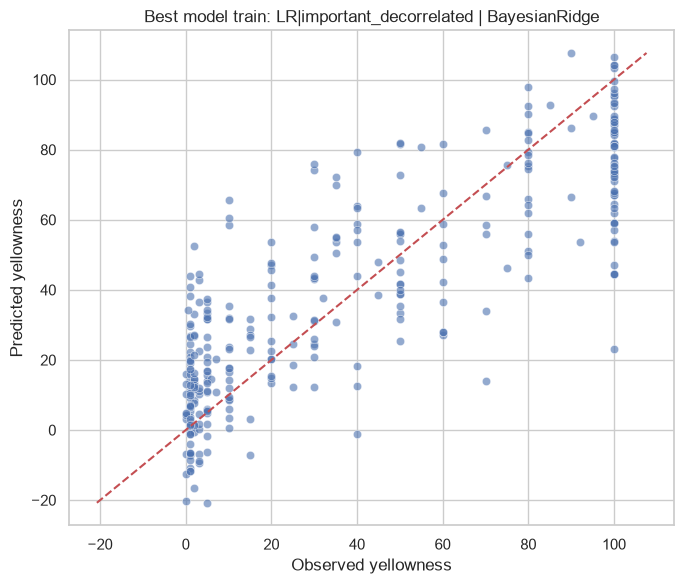

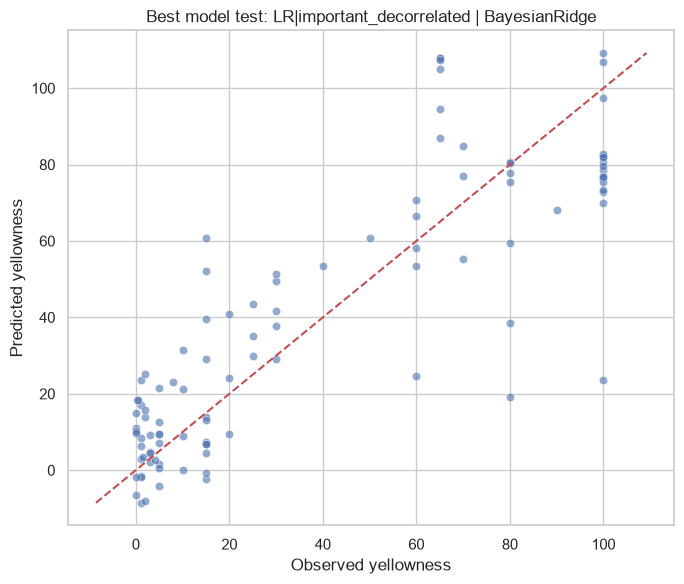

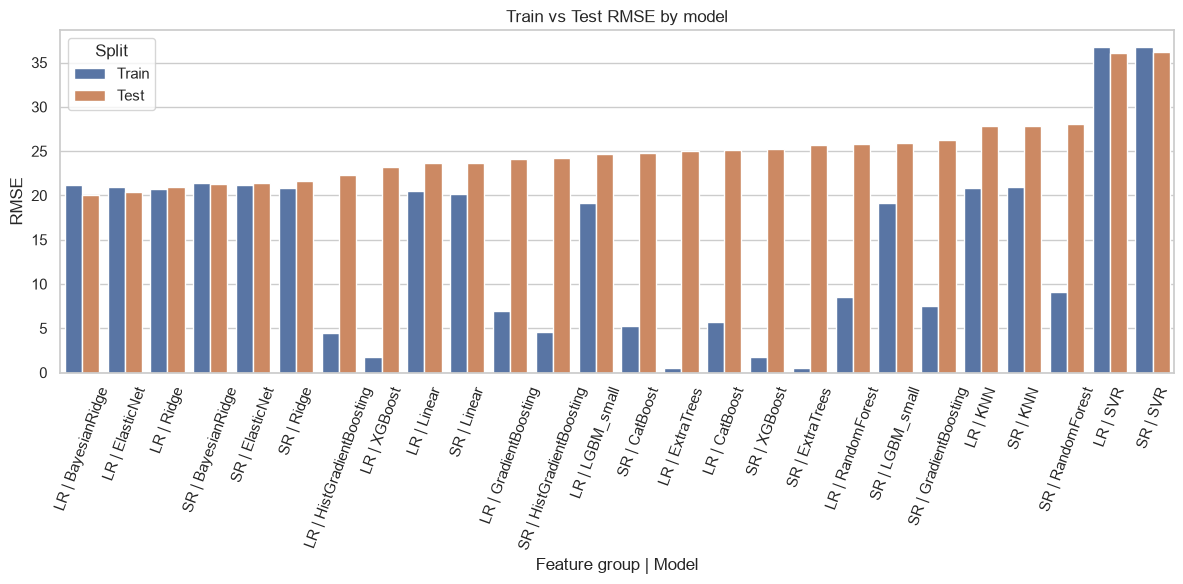

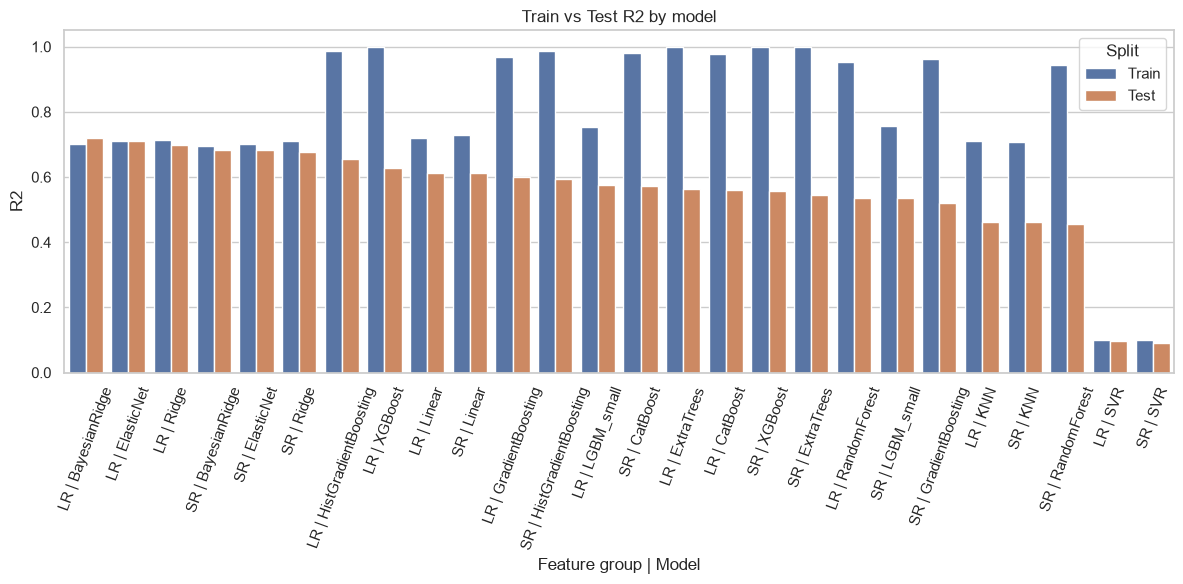

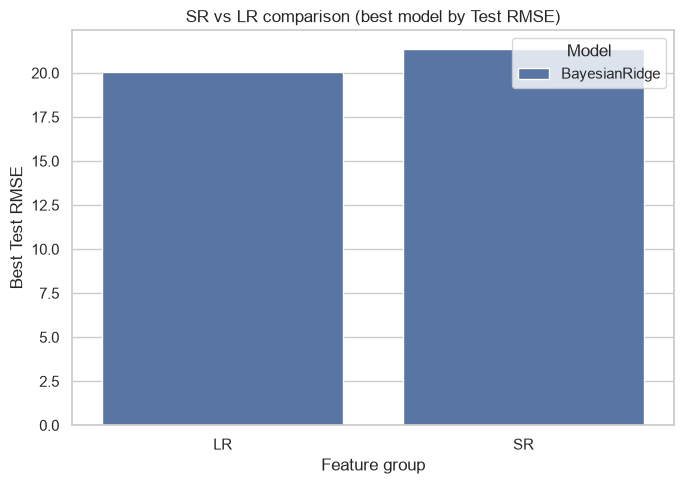

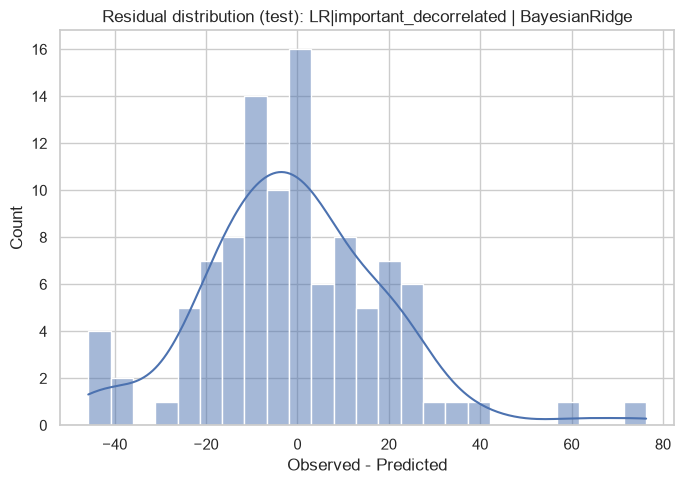

Saved figures to: C:\Users\ahtrabelsi\Desktop\stage\s2-super-resolution\outputs\evaluation_plots


,Feature_Group,Model,Test_RMSE,Test_R2,Test_MAE
0,LR,BayesianRidge,20.068346,0.720978,15.030522
1,SR,BayesianRidge,21.343665,0.684388,16.309647


In [9]:
# Step 9 - Plot evaluation results from the previous regression cell
# This cell creates separate figures and saves them so you can download them later.

results_plot = results_df.copy()
results_plot["Feature_Group"] = results_plot["Dataset"].str.split("|").str[0]

best_row = results_plot.sort_values(["Test_RMSE", "Test_MAE", "Test_R2"], ascending=[True, True, False]).iloc[0]
best_dataset = best_row["Dataset"]
best_model_name = best_row["Model"]
best_model = trained_models[(best_dataset, best_model_name)]

X_train_best = prepared_sets[best_dataset]["X_train"]
y_train_best = prepared_sets[best_dataset]["y_train"]
X_test_best = prepared_sets[best_dataset]["X_test"]
y_test_best = prepared_sets[best_dataset]["y_test"]

y_pred_train = best_model.predict(X_train_best)
y_pred_test = best_model.predict(X_test_best)

plot_dir = (repo_root if "repo_root" in globals() else Path.cwd()) / "outputs" / "evaluation_plots"
plot_dir.mkdir(parents=True, exist_ok=True)

# Figure 1: Best model train observed vs predicted
fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(x=y_train_best, y=y_pred_train, alpha=0.6, ax=ax)
lims = [
    float(np.nanmin([y_train_best.min(), y_pred_train.min()])),
    float(np.nanmax([y_train_best.max(), y_pred_train.max()])),
]
ax.plot(lims, lims, "r--", linewidth=1.5)
ax.set_title(f"Best model train: {best_dataset} | {best_model_name}")
ax.set_xlabel("Observed yellowness")
ax.set_ylabel("Predicted yellowness")
plt.tight_layout()
fig.savefig(plot_dir / "fig1_best_model_train_observed_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

# Figure 2: Best model test observed vs predicted
fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(x=y_test_best, y=y_pred_test, alpha=0.6, ax=ax)
lims = [
    float(np.nanmin([y_test_best.min(), y_pred_test.min()])),
    float(np.nanmax([y_test_best.max(), y_pred_test.max()])),
]
ax.plot(lims, lims, "r--", linewidth=1.5)
ax.set_title(f"Best model test: {best_dataset} | {best_model_name}")
ax.set_xlabel("Observed yellowness")
ax.set_ylabel("Predicted yellowness")
plt.tight_layout()
fig.savefig(plot_dir / "fig2_best_model_test_observed_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

# Figure 3: Train vs test RMSE for all models and datasets
fig, ax = plt.subplots(figsize=(12, 6))
plot_df = results_plot.melt(
    id_vars=["Dataset", "Feature_Group", "Model"],
    value_vars=["Train_RMSE", "Test_RMSE"],
    var_name="Split",
    value_name="RMSE",
)
plot_df["Split"] = plot_df["Split"].str.replace("_RMSE", "", regex=False)
plot_df["Label"] = plot_df["Feature_Group"] + " | " + plot_df["Model"]

sns.barplot(data=plot_df, x="Label", y="RMSE", hue="Split", ax=ax)
ax.set_title("Train vs Test RMSE by model")
ax.set_xlabel("Feature group | Model")
ax.set_ylabel("RMSE")
ax.tick_params(axis="x", rotation=70)
plt.tight_layout()
fig.savefig(plot_dir / "fig3_train_vs_test_rmse_all_models.png", dpi=300, bbox_inches="tight")
plt.show()

# Figure 4: Train vs test R2 for all models and datasets
fig, ax = plt.subplots(figsize=(12, 6))
plot_df_r2 = results_plot.melt(
    id_vars=["Dataset", "Feature_Group", "Model"],
    value_vars=["Train_R2", "Test_R2"],
    var_name="Split",
    value_name="R2",
)
plot_df_r2["Split"] = plot_df_r2["Split"].str.replace("_R2", "", regex=False)
plot_df_r2["Label"] = plot_df_r2["Feature_Group"] + " | " + plot_df_r2["Model"]

sns.barplot(data=plot_df_r2, x="Label", y="R2", hue="Split", ax=ax)
ax.set_title("Train vs Test R2 by model")
ax.set_xlabel("Feature group | Model")
ax.set_ylabel("R2")
ax.tick_params(axis="x", rotation=70)
plt.tight_layout()
fig.savefig(plot_dir / "fig4_train_vs_test_r2_all_models.png", dpi=300, bbox_inches="tight")
plt.show()

# Figure 5: SR vs LR comparison (best test RMSE per group)
best_per_group = (
    results_plot.sort_values(["Feature_Group", "Test_RMSE", "Test_MAE", "Test_R2"], ascending=[True, True, True, False])
    .groupby("Feature_Group", as_index=False)
    .first()
)

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=best_per_group, x="Feature_Group", y="Test_RMSE", hue="Model", ax=ax)
ax.set_title("SR vs LR comparison (best model by Test RMSE)")
ax.set_xlabel("Feature group")
ax.set_ylabel("Best Test RMSE")
plt.tight_layout()
fig.savefig(plot_dir / "fig5_sr_vs_lr_best_rmse.png", dpi=300, bbox_inches="tight")
plt.show()

# Figure 6: Residual distribution on test set for best model
residuals_test = y_test_best - y_pred_test
fig, ax = plt.subplots(figsize=(7, 5))
sns.histplot(residuals_test, bins=25, kde=True, ax=ax)
ax.set_title(f"Residual distribution (test): {best_dataset} | {best_model_name}")
ax.set_xlabel("Observed - Predicted")
ax.set_ylabel("Count")
plt.tight_layout()
fig.savefig(plot_dir / "fig6_best_model_test_residual_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved figures to:", plot_dir)
display(best_per_group[["Feature_Group", "Model", "Test_RMSE", "Test_R2", "Test_MAE"]])

In [10]:
from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    f1_score, classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import pandas as pd
import numpy as np


# -------------------------------------------------------
# Create severity classes
# -------------------------------------------------------

train_cls = train_df.copy()
test_cls = test_df.copy()

bins = [0, 10, 60, 100]
labels = ["low", "medium", "high"]

for d in [train_cls, test_cls]:
    d["severity"] = pd.cut(
        d[target],
        bins=bins,
        labels=labels,
        include_lowest=True
    ).astype(str)

print("Train classes:")
display(train_cls["severity"].value_counts(normalize=True).round(3))

print("Test classes:")
display(test_cls["severity"].value_counts(normalize=True).round(3))


# -------------------------------------------------------
# Models
# -------------------------------------------------------

cls_models = {

    "Logistic":
        make_pipeline(
            StandardScaler(),
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced"
            )
        ),

    "SVM":
        make_pipeline(
            StandardScaler(),
            SVC(
                kernel="rbf",
                C=1,
                class_weight="balanced"
            )
        ),

    "KNN":
        make_pipeline(
            StandardScaler(),
            KNeighborsClassifier(n_neighbors=5)
        ),

    "RandomForest":
        RandomForestClassifier(
            n_estimators=400,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ),

    "ExtraTrees":
        ExtraTreesClassifier(
            n_estimators=400,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ),

    "GradientBoosting":
        GradientBoostingClassifier(
            random_state=42
        ),

    "HistGradientBoosting":
        HistGradientBoostingClassifier(
            random_state=42
        )
}


# -------------------------------------------------------
# Training / evaluation
# -------------------------------------------------------

cls_results = []
trained_cls = {}


for dataset_key, features in selected_features_summary.items():

    group = dataset_key.split("|")[0]

    X_train = train_cls[features].copy()
    X_test = test_cls[features].copy()

    y_train = train_cls["severity"]
    y_test = test_cls["severity"]

    med = X_train.median()

    X_train = X_train.fillna(med)
    X_test = X_test.fillna(med)


    for name, model in cls_models.items():

        m = clone(model).fit(
            X_train,
            y_train
        )

        pred_train = m.predict(X_train)
        pred_test = m.predict(X_test)


        cls_results.append({

            "Feature_Group": group,
            "Model": name,

            "Train_Acc":
                accuracy_score(y_train, pred_train),

            "Test_Acc":
                accuracy_score(y_test, pred_test),

            "Train_F1":
                f1_score(
                    y_train,
                    pred_train,
                    average="macro"
                ),

            "Test_F1":
                f1_score(
                    y_test,
                    pred_test,
                    average="macro"
                ),

            "Test_Balanced_Acc":
                balanced_accuracy_score(
                    y_test,
                    pred_test
                ),

            "Acc_Gap":
                accuracy_score(y_train,pred_train)
                -
                accuracy_score(y_test,pred_test),

            "n_features": len(features)
        })

        trained_cls[(group,name)] = m


# -------------------------------------------------------
# Results
# -------------------------------------------------------

classification_results_df = (
    pd.DataFrame(cls_results)
    .sort_values(
        ["Test_F1","Test_Balanced_Acc"],
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    classification_results_df.round(3)
)

print("Best model:")
display(
    classification_results_df.head(1)
)

Train classes:


severity
low       0.427
high      0.296
medium    0.277
Name: proportion, dtype: float64

Test classes:


severity
low       0.375
high      0.337
medium    0.288
Name: proportion, dtype: float64

,Feature_Group,Model,Train_Acc,Test_Acc,Train_F1,Test_F1,Test_Balanced_Acc,Acc_Gap,n_features
0,LR,Logistic,0.829,0.750,0.823,0.729,0.730,0.079,40
1,SR,Logistic,0.804,0.712,0.797,0.701,0.697,0.092,40
2,LR,SVM,0.835,0.673,0.829,0.656,0.655,0.162,40
3,SR,SVM,0.810,0.644,0.802,0.635,0.629,0.166,40
4,LR,RandomForest,0.997,0.644,0.997,0.632,0.630,0.353,40
5,SR,ExtraTrees,0.997,0.654,0.997,0.630,0.632,0.343,40
6,SR,RandomForest,0.997,0.635,0.997,0.628,0.624,0.362,40
7,LR,ExtraTrees,0.997,0.644,0.997,0.620,0.623,0.353,40
8,LR,HistGradientBoosting,0.997,0.654,0.997,0.614,0.624,0.343,40
9,LR,GradientBoosting,0.997,0.635,0.997,0.605,0.609,0.362,40


Best model:


,Feature_Group,Model,Train_Acc,Test_Acc,Train_F1,Test_F1,Test_Balanced_Acc,Acc_Gap,n_features
0,LR,Logistic,0.82866,0.75,0.822867,0.728592,0.729915,0.07866,40


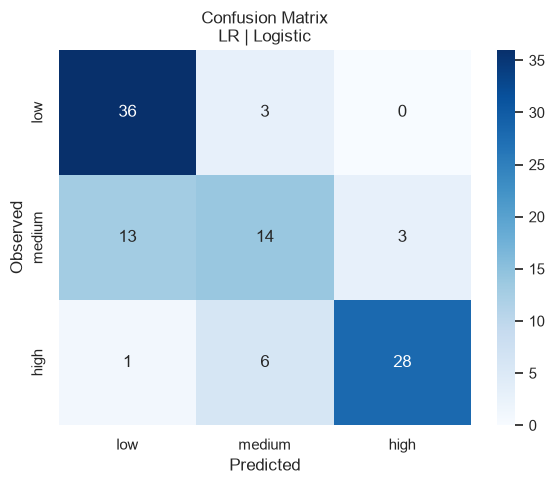

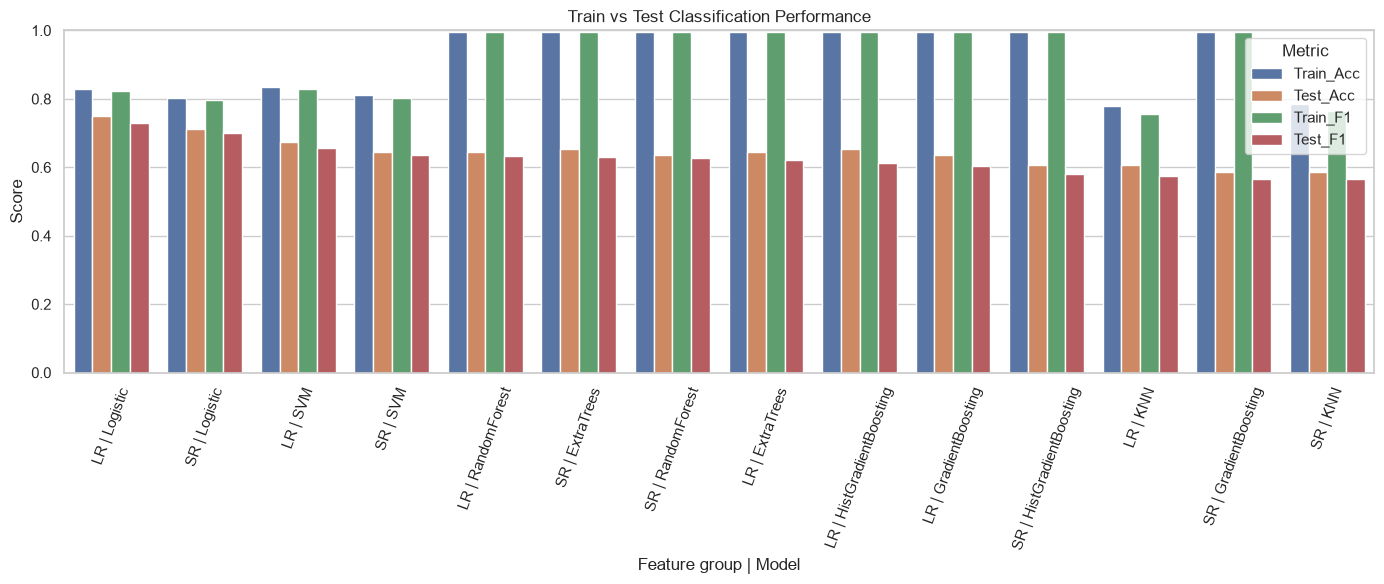

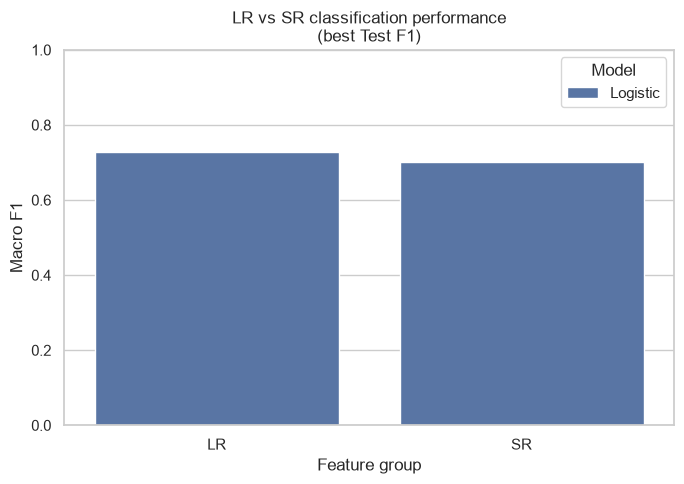

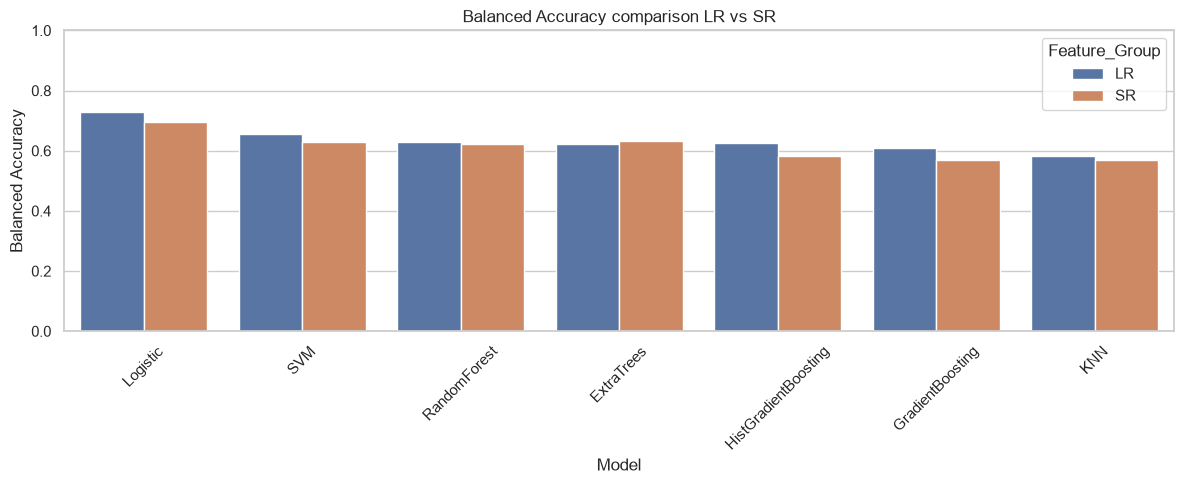

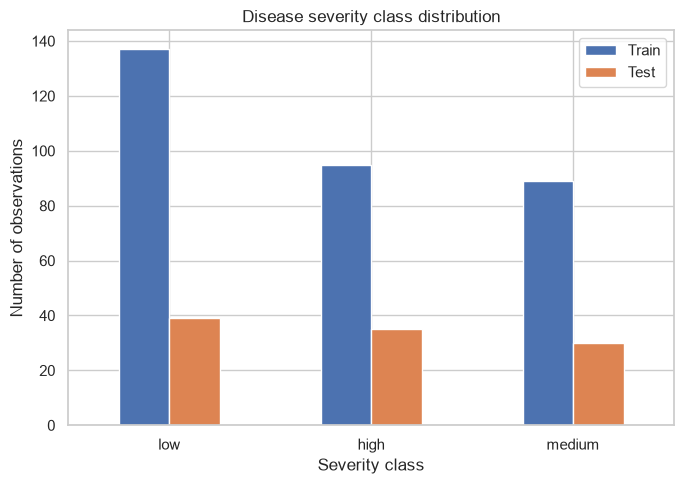

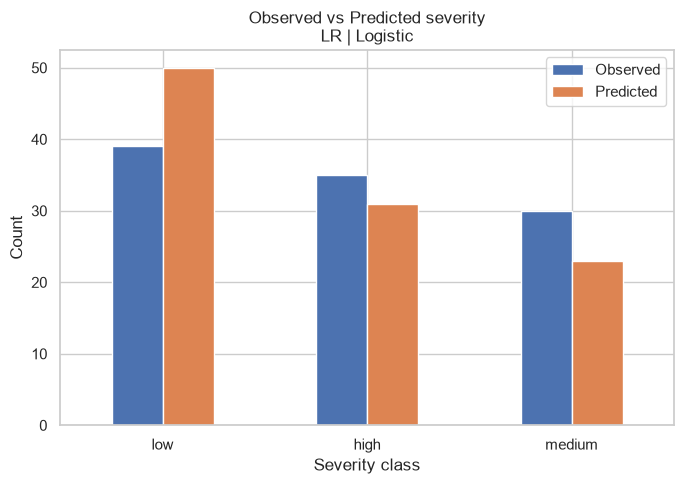

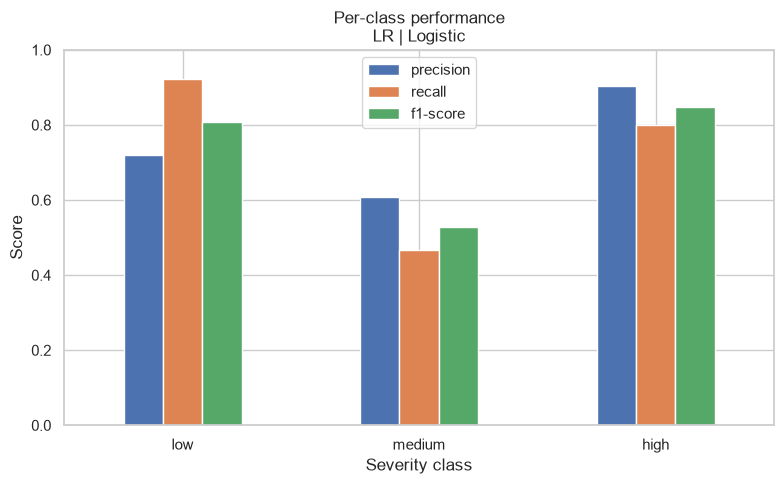

Saved classification figures to: C:\Users\ahtrabelsi\Desktop\stage\s2-super-resolution\outputs\classification_plots

Best classification configuration:


,Feature_Group,Model,Train_Acc,Test_Acc,Train_F1,Test_F1,Test_Balanced_Acc,Acc_Gap,n_features
0,LR,Logistic,0.82866,0.75,0.822867,0.728592,0.729915,0.07866,40



Classification report:


,precision,recall,f1-score
low,0.720,0.923,0.809
medium,0.609,0.467,0.528
high,0.903,0.800,0.848


In [11]:
# Step 11 - Classification evaluation plots

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

from pathlib import Path


plot_dir = (
    repo_root if "repo_root" in globals() else Path.cwd()
) / "outputs" / "classification_plots"

plot_dir.mkdir(parents=True, exist_ok=True)


# -------------------------------------------------------
# Best classification model
# -------------------------------------------------------

best_cls = classification_results_df.iloc[0]

best_group = best_cls["Feature_Group"]
best_model_name = best_cls["Model"]

best_model = trained_cls[(best_group, best_model_name)]

features = selected_features_summary[
    f"{best_group}|important_decorrelated"
]


X_train = train_cls[features].fillna(
    train_cls[features].median()
)

X_test = test_cls[features].fillna(
    train_cls[features].median()
)

y_train = train_cls["severity"]
y_test = test_cls["severity"]


pred_train = best_model.predict(X_train)
pred_test = best_model.predict(X_test)


classes = ["low", "medium", "high"]



# -------------------------------------------------------
# Figure 1 - Confusion matrix best model
# -------------------------------------------------------

cm = confusion_matrix(
    y_test,
    pred_test,
    labels=classes
)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes,
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Observed")
plt.title(
    f"Confusion Matrix\n{best_group} | {best_model_name}"
)

plt.tight_layout()
plt.savefig(
    plot_dir / "fig1_best_model_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



# -------------------------------------------------------
# Figure 2 - Train vs Test performance all models
# -------------------------------------------------------

perf_plot = classification_results_df.melt(
    id_vars=[
        "Feature_Group",
        "Model"
    ],
    value_vars=[
        "Train_Acc",
        "Test_Acc",
        "Train_F1",
        "Test_F1"
    ],
    var_name="Metric",
    value_name="Score"
)


perf_plot["Label"] = (
    perf_plot["Feature_Group"]
    + " | "
    + perf_plot["Model"]
)


plt.figure(figsize=(14,6))

sns.barplot(
    data=perf_plot,
    x="Label",
    y="Score",
    hue="Metric"
)

plt.xticks(rotation=70)
plt.ylim(0,1)

plt.title(
    "Train vs Test Classification Performance"
)

plt.xlabel("Feature group | Model")
plt.ylabel("Score")

plt.tight_layout()

plt.savefig(
    plot_dir / "fig2_train_test_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



# -------------------------------------------------------
# Figure 3 - LR vs SR comparison
# -------------------------------------------------------

best_group_results = (
    classification_results_df
    .sort_values(
        [
            "Feature_Group",
            "Test_F1"
        ],
        ascending=False
    )
    .groupby("Feature_Group")
    .first()
    .reset_index()
)


plt.figure(figsize=(7,5))

sns.barplot(
    data=best_group_results,
    x="Feature_Group",
    y="Test_F1",
    hue="Model"
)

plt.title(
    "LR vs SR classification performance\n(best Test F1)"
)

plt.xlabel("Feature group")
plt.ylabel("Macro F1")

plt.ylim(0,1)

plt.tight_layout()

plt.savefig(
    plot_dir / "fig3_lr_vs_sr_best_f1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



# -------------------------------------------------------
# Figure 4 - Balanced accuracy comparison
# -------------------------------------------------------

plt.figure(figsize=(12,5))

sns.barplot(
    data=classification_results_df,
    x="Model",
    y="Test_Balanced_Acc",
    hue="Feature_Group"
)

plt.xticks(rotation=45)
plt.ylim(0,1)

plt.title(
    "Balanced Accuracy comparison LR vs SR"
)

plt.ylabel("Balanced Accuracy")

plt.tight_layout()

plt.savefig(
    plot_dir / "fig4_balanced_accuracy_models.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



# -------------------------------------------------------
# Figure 5 - Severity class distribution
# -------------------------------------------------------

distribution = pd.DataFrame({
    "Train": train_cls["severity"].value_counts(),
    "Test": test_cls["severity"].value_counts()
}).fillna(0)


distribution.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title(
    "Disease severity class distribution"
)

plt.xlabel("Severity class")
plt.ylabel("Number of observations")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    plot_dir / "fig5_class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



# -------------------------------------------------------
# Figure 6 - Prediction distribution
# -------------------------------------------------------

pred_distribution = pd.DataFrame({

    "Observed": y_test.value_counts(),

    "Predicted": pd.Series(pred_test).value_counts()

}).fillna(0)


pred_distribution.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title(
    f"Observed vs Predicted severity\n{best_group} | {best_model_name}"
)

plt.xlabel("Severity class")
plt.ylabel("Count")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    plot_dir / "fig6_observed_vs_predicted_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



# -------------------------------------------------------
# Figure 7 - Per class F1 / Precision / Recall
# -------------------------------------------------------

report = pd.DataFrame(
    classification_report(
        y_test,
        pred_test,
        output_dict=True
    )
).T


class_report = report.loc[
    classes,
    [
        "precision",
        "recall",
        "f1-score"
    ]
]


class_report.plot(
    kind="bar",
    figsize=(8,5)
)

plt.ylim(0,1)

plt.title(
    f"Per-class performance\n{best_group} | {best_model_name}"
)

plt.xlabel("Severity class")
plt.ylabel("Score")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    plot_dir / "fig7_per_class_metrics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



# -------------------------------------------------------
# Summary
# -------------------------------------------------------

print("Saved classification figures to:", plot_dir)

print("\nBest classification configuration:")
display(
    classification_results_df.head(1)
)

print("\nClassification report:")
display(class_report.round(3))

In [35]:
from sklearn.model_selection import GroupKFold
from sklearn.base import clone
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Step 12 - 5-fold Group CV with fold-wise preprocessing, feature selection, OOF predictions, and fold diagnostics
if "id_plot" not in df.columns: raise ValueError("id_plot is required for group-based CV.")
if target not in df.columns: raise ValueError(f"{target} column is required.")
if "models" not in globals(): raise ValueError("models dict not found. Run the regression-model cell first.")
if not {"lr_full_pool","sr_full_pool","meta_features"}.issubset(globals()): raise ValueError("Feature pools not found. Run Step 6 first.")

candidate_feature_groups = {"LR": sorted(set(lr_full_pool + meta_features)), "SR": sorted(set(sr_full_pool + meta_features))}
# Convert % values (e.g. 0..100) to a 0..1 scale for regression targets.
# This keeps observations and predictions in the [0, 1] range.
target_scale = 100.0
if target in df.columns:
    target_vals = pd.to_numeric(df[target], errors="coerce")
    if target_vals.notna().any() and target_vals.max() > 1.0:
        df[target] = target_vals / target_scale
def drop_high_corr_train_only(X_train, threshold=0.8):
    if X_train.shape[1] <= 1: return X_train.columns.tolist()
    corr_mat = X_train.corr(numeric_only=True).abs(); upper = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool)); to_drop = [c for c in upper.columns if any(upper[c] > threshold)]
    return [c for c in X_train.columns if c not in to_drop]

def prepare_fold_dataset(train_frame, valid_frame, feature_candidates, top_k=40, corr_threshold=0.98):
    cols = [c for c in feature_candidates if c in train_frame.columns and c in valid_frame.columns]
    if not cols: return None
    X_train_raw, X_valid_raw = train_frame[cols].copy(), valid_frame[cols].copy(); y_train, y_valid = train_frame[target].astype(float).copy(), valid_frame[target].astype(float).copy()
    medians = X_train_raw.median(numeric_only=True); X_train_imp, X_valid_imp = X_train_raw.fillna(medians), X_valid_raw.fillna(medians)
    kept = drop_high_corr_train_only(X_train_imp, threshold=corr_threshold)
    if not kept: return None
    X_train_dec, X_valid_dec = X_train_imp[kept], X_valid_imp[kept]; k = min(top_k, X_train_dec.shape[1])
    mi = mutual_info_regression(X_train_dec, y_train, random_state=42); selected = pd.Series(mi, index=X_train_dec.columns).sort_values(ascending=False).head(k).index.tolist()
    return {"X_train": X_train_dec[selected], "X_valid": X_valid_dec[selected], "y_train": y_train, "y_valid": y_valid, "selected_features": selected}

cv_frame = df.dropna(subset=[target, "id_plot"]).copy().reset_index(drop=False).rename(columns={"index":"Original_Index"})
gkf = GroupKFold(n_splits=5, shuffle=True, random_state=42)
cv_rows, fold_composition_rows, fold_feature_log, oof_rows = [], [], [], []

for fold_idx, (tr_idx, va_idx) in enumerate(gkf.split(cv_frame, groups=cv_frame["id_plot"]), start=1):
    fold_train, fold_valid = cv_frame.iloc[tr_idx].copy(), cv_frame.iloc[va_idx].copy()
    fold_composition_rows.append({"Fold":fold_idx,"Train_n":len(fold_train),"Valid_n":len(fold_valid),"Train_parcels":fold_train["id_plot"].nunique(),"Valid_parcels":fold_valid["id_plot"].nunique(),"Train_mean":fold_train[target].mean(),"Valid_mean":fold_valid[target].mean(),"Train_median":fold_train[target].median(),"Valid_median":fold_valid[target].median(),"Train_std":fold_train[target].std(),"Valid_std":fold_valid[target].std(),"Train_min":fold_train[target].min(),"Valid_min":fold_valid[target].min(),"Train_max":fold_train[target].max(),"Valid_max":fold_valid[target].max()})
    for feature_group, candidates in candidate_feature_groups.items():
        fold_data = prepare_fold_dataset(fold_train, fold_valid, candidates, top_k=40, corr_threshold=0.98)
        if fold_data is None: continue
        X_train, X_valid, y_train, y_valid = fold_data["X_train"], fold_data["X_valid"], fold_data["y_train"], fold_data["y_valid"]
        fold_feature_log.append({"Fold":fold_idx,"Feature_Group":feature_group,"n_selected_features":len(fold_data["selected_features"]),"selected_features":fold_data["selected_features"]})
        baseline_pred = np.full(len(y_valid), y_train.mean()); baseline_mae = mean_absolute_error(y_valid, baseline_pred); baseline_rmse = np.sqrt(mean_squared_error(y_valid, baseline_pred)); baseline_r2 = r2_score(y_valid, baseline_pred)
        for model_name, model in models.items():
            m = clone(model).fit(X_train, y_train); pred_tr, pred_va = m.predict(X_train), m.predict(X_valid); tr_rmse, va_rmse = np.sqrt(mean_squared_error(y_train,pred_tr)), np.sqrt(mean_squared_error(y_valid,pred_va)); tr_r2, va_r2 = r2_score(y_train,pred_tr), r2_score(y_valid,pred_va)
            cv_rows.append({"Fold":fold_idx,"Feature_Group":feature_group,"Model":model_name,"n_features":X_train.shape[1],"Train_MAE":mean_absolute_error(y_train,pred_tr),"Valid_MAE":mean_absolute_error(y_valid,pred_va),"Train_RMSE":tr_rmse,"Valid_RMSE":va_rmse,"Train_R2":tr_r2,"Valid_R2":va_r2,"RMSE_Gap":va_rmse-tr_rmse,"R2_Gap":tr_r2-va_r2,"Baseline_MAE":baseline_mae,"Baseline_RMSE":baseline_rmse,"Baseline_R2":baseline_r2,"RMSE_Improvement_pct":100*(baseline_rmse-va_rmse)/baseline_rmse})
            oof_rows.extend([{"Original_Index":idx,"Fold":fold_idx,"Feature_Group":feature_group,"Model":model_name,"y_true":y,"y_pred":p} for idx,y,p in zip(fold_valid["Original_Index"],y_valid,pred_va)])

fold_composition_df = pd.DataFrame(fold_composition_rows)
cv_results_df = pd.DataFrame(cv_rows)
fold_feature_log_df = pd.DataFrame(fold_feature_log)
oof_predictions_df = pd.DataFrame(oof_rows)

def summarize_group(g):
    feature_group, model_name = g.name
    y_true, y_pred = g["y_true"].to_numpy(), g["y_pred"].to_numpy()
    return pd.Series({"Folds":g["Fold"].nunique(),"N_OOF":len(g),"Features_mean":cv_results_df.query("Feature_Group == @feature_group and Model == @model_name")["n_features"].mean(),"Valid_MAE_mean":g["Fold"].map(cv_results_df.set_index(["Fold","Feature_Group","Model"])["Valid_MAE"]).mean(),"Valid_MAE_std":g["Fold"].map(cv_results_df.set_index(["Fold","Feature_Group","Model"])["Valid_MAE"]).std(),"Valid_RMSE_mean":g["Fold"].map(cv_results_df.set_index(["Fold","Feature_Group","Model"])["Valid_RMSE"]).mean(),"Valid_RMSE_std":g["Fold"].map(cv_results_df.set_index(["Fold","Feature_Group","Model"])["Valid_RMSE"]).std(),"Valid_R2_mean":g["Fold"].map(cv_results_df.set_index(["Fold","Feature_Group","Model"])["Valid_R2"]).mean(),"Valid_R2_median":g["Fold"].map(cv_results_df.set_index(["Fold","Feature_Group","Model"])["Valid_R2"]).median(),"Valid_R2_std":g["Fold"].map(cv_results_df.set_index(["Fold","Feature_Group","Model"])["Valid_R2"]).std(),"Valid_R2_min":g["Fold"].map(cv_results_df.set_index(["Fold","Feature_Group","Model"])["Valid_R2"]).min(),"Valid_R2_max":g["Fold"].map(cv_results_df.set_index(["Fold","Feature_Group","Model"])["Valid_R2"]).max(),"OOF_MAE":mean_absolute_error(y_true,y_pred),"OOF_RMSE":np.sqrt(mean_squared_error(y_true,y_pred)),"OOF_R2":r2_score(y_true,y_pred)})

cv_summary_df = oof_predictions_df.groupby(["Feature_Group","Model"],group_keys=False).apply(summarize_group,include_groups=False).reset_index()
cv_summary_df = cv_summary_df.sort_values(["OOF_RMSE","OOF_MAE","OOF_R2"],ascending=[True,True,False]).reset_index(drop=True)

fold_summary = cv_results_df.groupby(["Feature_Group","Model"],as_index=False).agg(
    Folds=("Fold","count"),
    Features_mean=("n_features","mean"),
    Train_MAE_mean=("Train_MAE","mean"),
    Train_RMSE_mean=("Train_RMSE","mean"),
    Train_R2_mean=("Train_R2","mean"),
    Valid_MAE_mean=("Valid_MAE","mean"),
    Valid_MAE_std=("Valid_MAE","std"),
    Valid_RMSE_mean=("Valid_RMSE","mean"),
    Valid_RMSE_std=("Valid_RMSE","std"),
    Valid_R2_mean=("Valid_R2","mean"),
    Valid_R2_median=("Valid_R2","median"),
    Valid_R2_std=("Valid_R2","std"),
    Valid_R2_min=("Valid_R2","min"),
    Valid_R2_max=("Valid_R2","max"),
    RMSE_Gap_mean=("RMSE_Gap","mean"),
    R2_Gap_mean=("R2_Gap","mean"),
    Baseline_RMSE_mean=("Baseline_RMSE","mean"),
    RMSE_Improvement_mean_pct=("RMSE_Improvement_pct","mean")
)

# Calculate overall OOF performance separately for each Feature Group + Model
oof_summary = oof_predictions_df.groupby(["Feature_Group","Model"],as_index=False).apply(
    lambda g: pd.Series({
        "OOF_MAE": mean_absolute_error(g["y_true"],g["y_pred"]),
        "OOF_RMSE": np.sqrt(mean_squared_error(g["y_true"],g["y_pred"])),
        "OOF_R2": r2_score(g["y_true"],g["y_pred"])
    }),
    include_groups=False
).reset_index(drop=True)

# Combine fold-level averages with overall OOF performance
overall_performance_df = fold_summary.merge(
    oof_summary,
    on=["Feature_Group","Model"],
    how="left"
).sort_values(
    ["OOF_RMSE","OOF_MAE","OOF_R2"],
    ascending=[True,True,False]
).reset_index(drop=True)

# Display the final model comparison
display(overall_performance_df.round(4))
overall_performance_df.to_csv("C:\\Users\\ahtrabelsi\\Desktop\\stage\\s2-super-resolution\\outputs\\ML_regression\\ML_regression_overall_performance_summary.csv", index=False)

,Feature_Group,Model,Folds,Features_mean,Train_MAE_mean,Train_RMSE_mean,Train_R2_mean,Valid_MAE_mean,Valid_MAE_std,Valid_RMSE_mean,Valid_RMSE_std,Valid_R2_mean,Valid_R2_median,Valid_R2_std,Valid_R2_min,Valid_R2_max,RMSE_Gap_mean,R2_Gap_mean,Baseline_RMSE_mean,RMSE_Improvement_mean_pct,OOF_MAE,OOF_RMSE,OOF_R2
0,SR,BayesianRidge,5,40.0,0.1594,0.2054,0.7147,0.1850,0.0290,0.2363,0.0349,0.5827,0.6085,0.0870,0.4562,0.6597,0.0309,0.1320,0.3858,38.5150,0.1909,0.2444,0.5986
1,SR,Ridge,5,40.0,0.1552,0.2010,0.7267,0.1865,0.0279,0.2386,0.0341,0.5746,0.5821,0.0836,0.4597,0.6637,0.0376,0.1521,0.3858,37.8893,0.1920,0.2462,0.5929
2,LR,BayesianRidge,5,40.0,0.1554,0.2009,0.7266,0.1824,0.0408,0.2357,0.0501,0.5772,0.6700,0.1558,0.3765,0.7163,0.0348,0.1495,0.3858,38.6314,0.1907,0.2493,0.5825
3,LR,ElasticNet,5,40.0,0.1704,0.2171,0.6809,0.1908,0.0293,0.2416,0.0317,0.5575,0.5953,0.1217,0.3500,0.6496,0.0245,0.1234,0.3858,36.9546,0.1970,0.2497,0.5811
4,SR,ElasticNet,5,40.0,0.1764,0.2234,0.6623,0.1968,0.0216,0.2447,0.0246,0.5514,0.5748,0.0704,0.4280,0.6029,0.0213,0.1109,0.3858,36.2765,0.2013,0.2503,0.5792
5,LR,Ridge,5,40.0,0.1527,0.1979,0.7349,0.1841,0.0436,0.2385,0.0545,0.5637,0.6463,0.1753,0.3491,0.7406,0.0407,0.1712,0.3858,37.8713,0.1926,0.2535,0.5684
6,SR,SVR,5,40.0,0.1100,0.1475,0.8520,0.1961,0.0230,0.2512,0.0282,0.5040,0.6119,0.2011,0.1804,0.6467,0.1037,0.3480,0.3858,33.9613,0.1994,0.2561,0.5593
7,LR,XGBoost,5,40.0,0.0122,0.0168,0.9981,0.1921,0.0222,0.2524,0.0325,0.5053,0.5997,0.1920,0.1712,0.6376,0.2356,0.4928,0.3858,33.8309,0.1966,0.2593,0.5482
8,SR,Linear,5,40.0,0.1511,0.1960,0.7402,0.1977,0.0205,0.2547,0.0260,0.5119,0.5147,0.0868,0.3873,0.6317,0.0587,0.2283,0.3858,33.5392,0.2019,0.2600,0.5459
9,LR,HistGradientBoosting,5,40.0,0.0279,0.0411,0.9886,0.1945,0.0229,0.2560,0.0272,0.4957,0.5369,0.1643,0.2148,0.6237,0.2149,0.4929,0.3858,32.9341,0.1987,0.2614,0.5411


Selected top models:


,Feature_Group,Model,OOF_MAE,OOF_RMSE,OOF_R2,Valid_R2_mean,Valid_R2_std
0,SR,BayesianRidge,0.1909,0.2444,0.5986,0.5827,0.0870
1,SR,Ridge,0.1920,0.2462,0.5929,0.5746,0.0836
2,LR,BayesianRidge,0.1907,0.2493,0.5825,0.5772,0.1558
3,LR,ElasticNet,0.1970,0.2497,0.5811,0.5575,0.1217
4,SR,ElasticNet,0.2013,0.2503,0.5792,0.5514,0.0704
5,LR,Ridge,0.1926,0.2535,0.5684,0.5637,0.1753


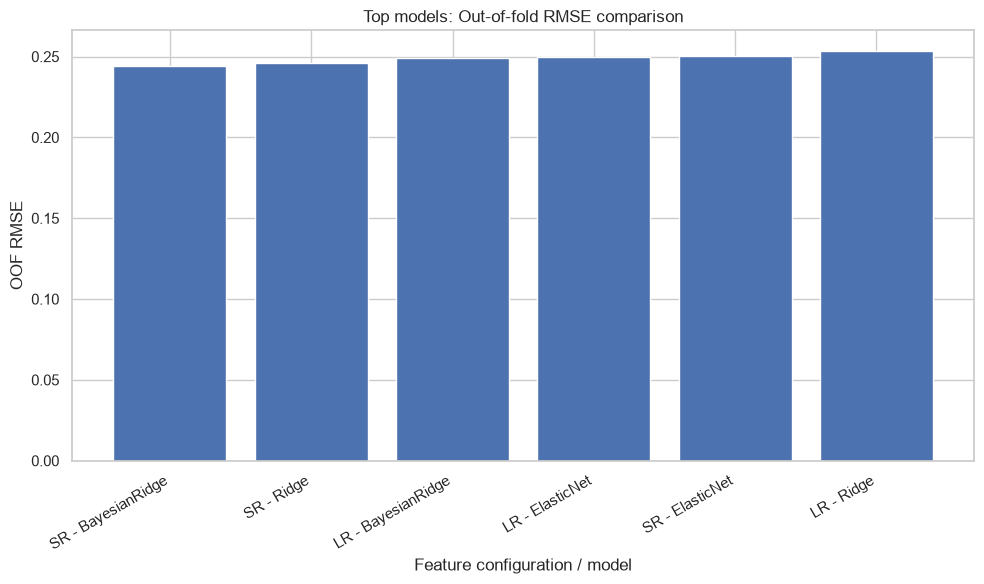

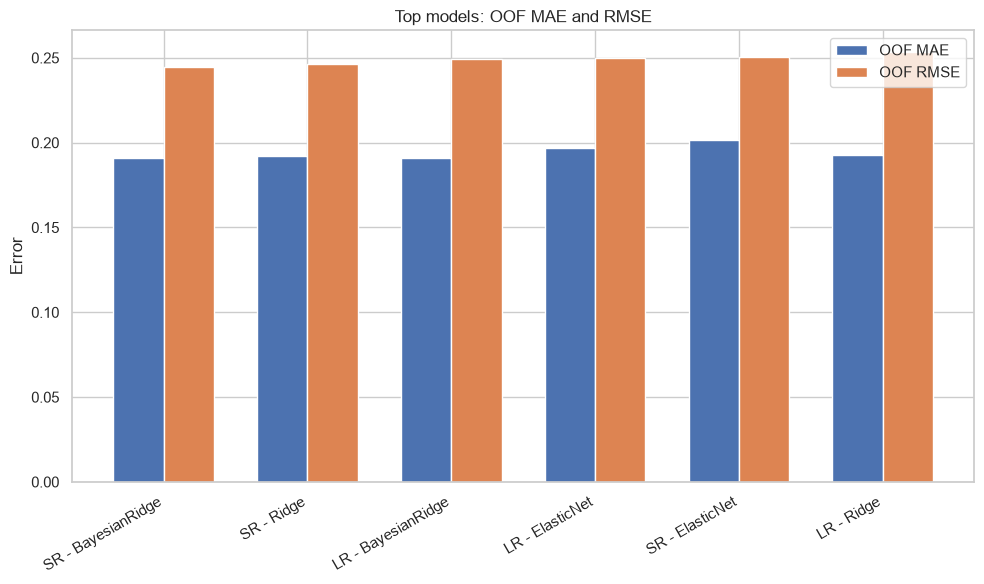

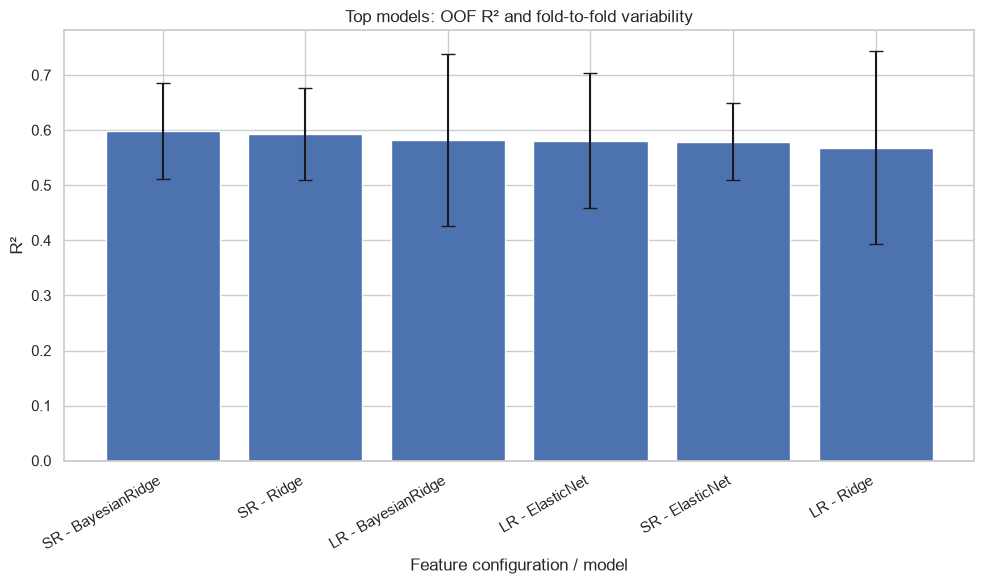

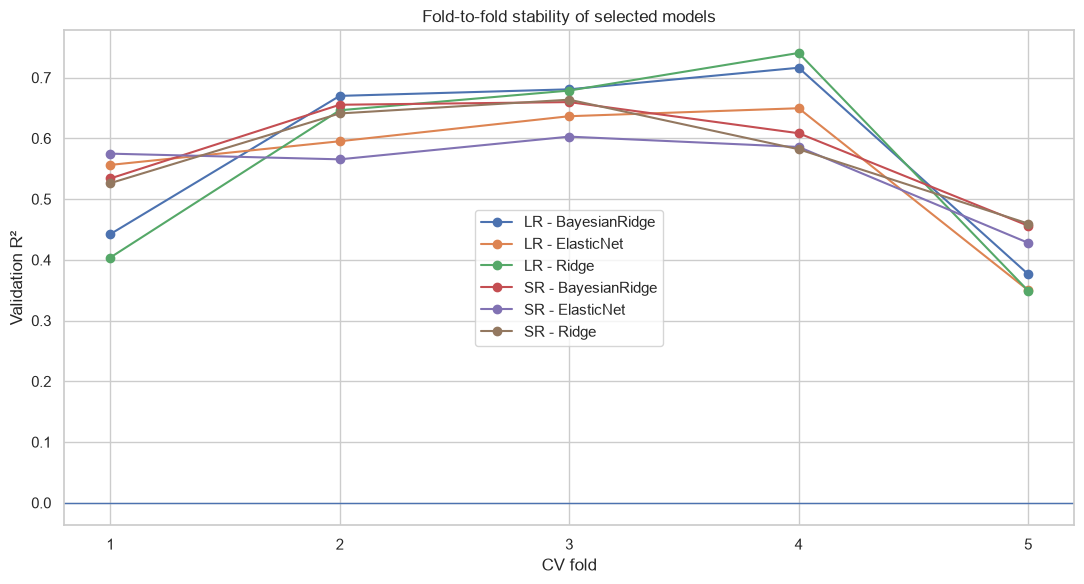

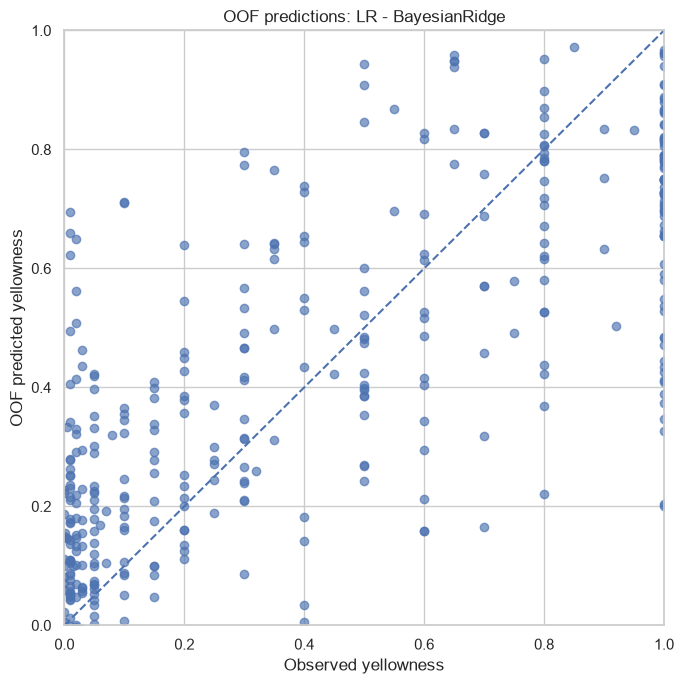

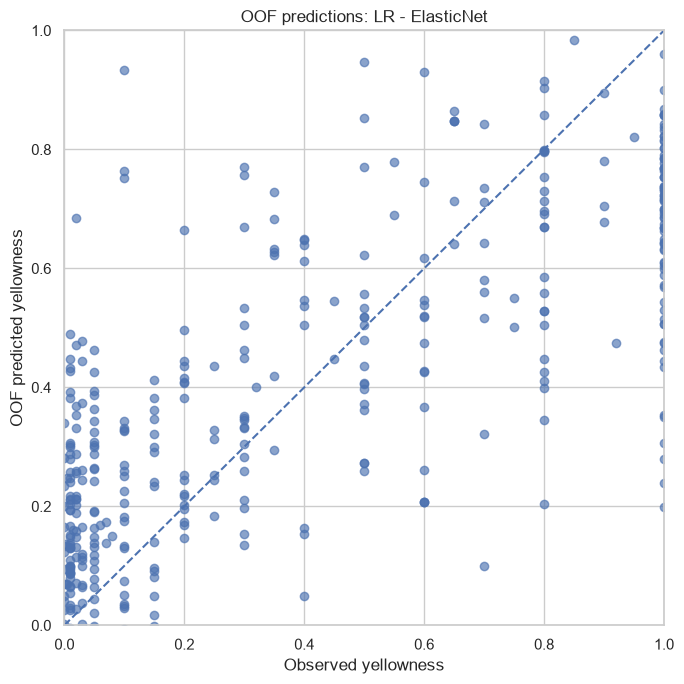

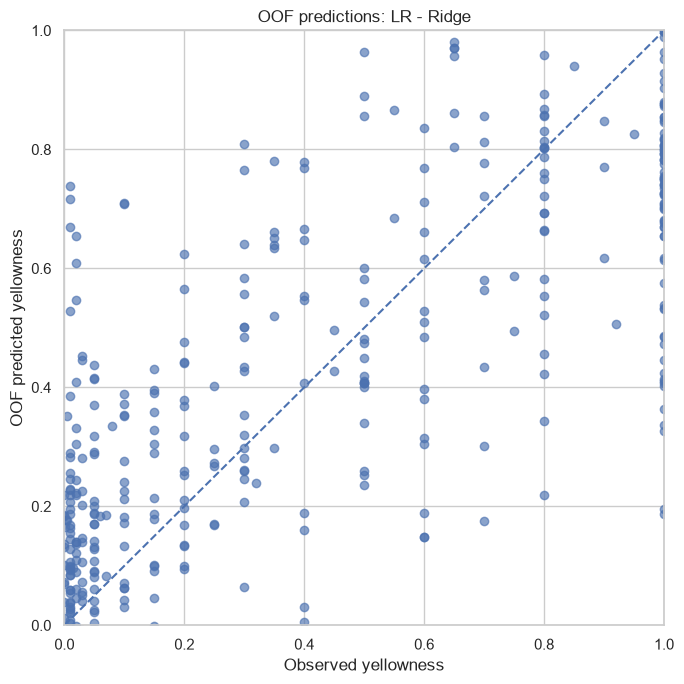

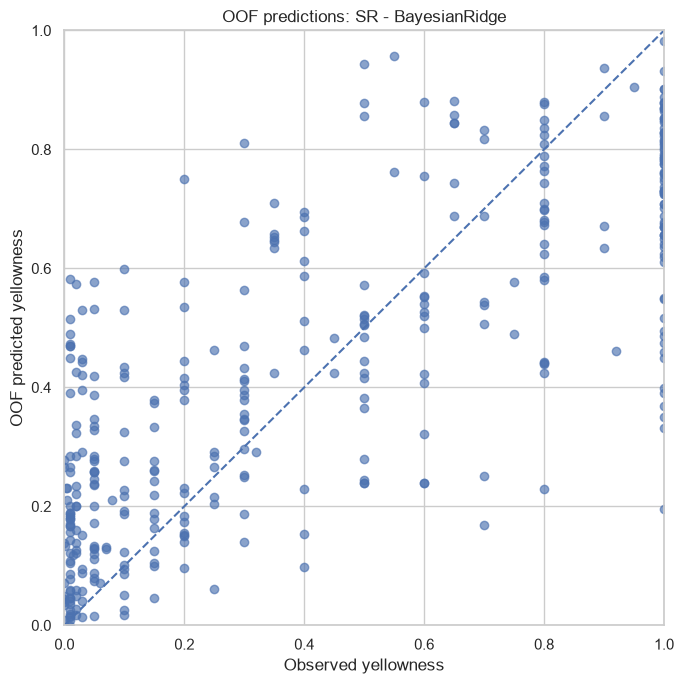

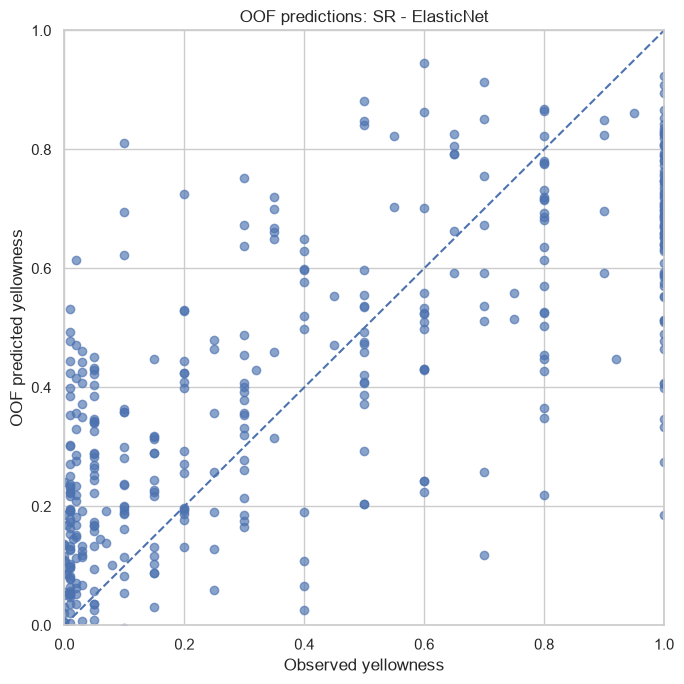

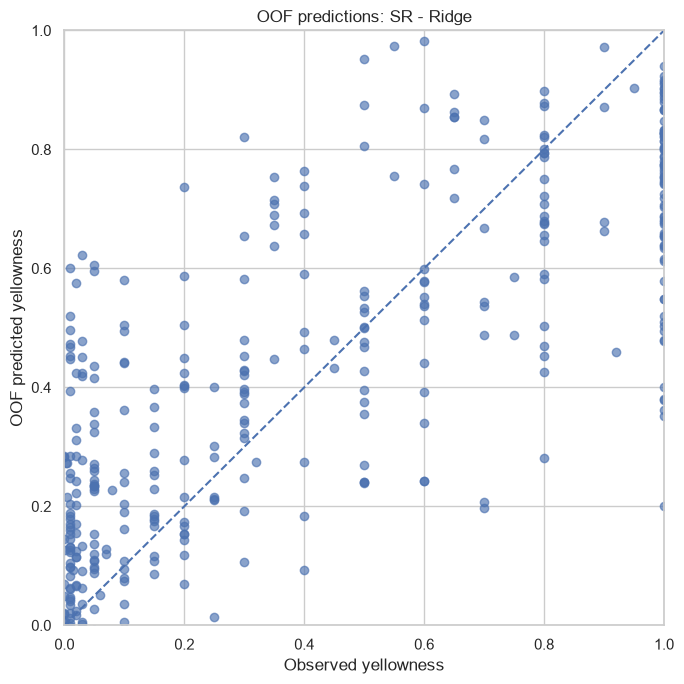

,Feature_Group,Model,Features_mean,Valid_MAE_mean,Valid_MAE_std,Valid_RMSE_mean,Valid_RMSE_std,Valid_R2_mean,Valid_R2_std,OOF_MAE,OOF_RMSE,OOF_R2
0,SR,BayesianRidge,40.0,0.1850,0.0290,0.2363,0.0349,0.5827,0.0870,0.1909,0.2444,0.5986
1,SR,Ridge,40.0,0.1865,0.0279,0.2386,0.0341,0.5746,0.0836,0.1920,0.2462,0.5929
2,LR,BayesianRidge,40.0,0.1824,0.0408,0.2357,0.0501,0.5772,0.1558,0.1907,0.2493,0.5825
3,LR,ElasticNet,40.0,0.1908,0.0293,0.2416,0.0317,0.5575,0.1217,0.1970,0.2497,0.5811
4,SR,ElasticNet,40.0,0.1968,0.0216,0.2447,0.0246,0.5514,0.0704,0.2013,0.2503,0.5792
5,LR,Ridge,40.0,0.1841,0.0436,0.2385,0.0545,0.5637,0.1753,0.1926,0.2535,0.5684


In [37]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import os

figures_dir = r"C:\Users\ahtrabelsi\Desktop\stage\s2-super-resolution\outputs\ML_regression\figures"
os.makedirs(figures_dir, exist_ok=True)

# Select top 2 models separately for LR and SR using lowest OOF RMSE
top_models_df = (overall_performance_df.sort_values("OOF_RMSE").groupby("Feature_Group",group_keys=False).head(3).reset_index(drop=True))
print("Selected top models:")
display(top_models_df[["Feature_Group","Model","OOF_MAE","OOF_RMSE","OOF_R2","Valid_R2_mean","Valid_R2_std"]].round(4))

# Create readable model labels
top_models_df["Config_Model"] = top_models_df["Feature_Group"] + " - " + top_models_df["Model"]
top_keys = top_models_df[["Feature_Group","Model"]].drop_duplicates()

# Plot 1 - OOF RMSE comparison
plot_df = top_models_df.sort_values("OOF_RMSE")
plt.figure(figsize=(10,6))
plt.bar(plot_df["Config_Model"],plot_df["OOF_RMSE"])
plt.ylabel("OOF RMSE")
plt.xlabel("Feature configuration / model")
plt.title("Top models: Out-of-fold RMSE comparison")
plt.xticks(rotation=30,ha="right")
plt.tight_layout()
plt.savefig(
    os.path.join(figures_dir, "OOF_RMSE_comparison.pdf"),
    format="pdf",
    bbox_inches="tight"
)
plt.show()

# Plot 2 - OOF MAE and R² comparison
fig, ax1 = plt.subplots(figsize=(10,6))
x = np.arange(len(plot_df))
width = 0.35
ax1.bar(x-width/2,plot_df["OOF_MAE"],width,label="OOF MAE")
ax1.bar(x+width/2,plot_df["OOF_RMSE"],width,label="OOF RMSE")
ax1.set_xticks(x)
ax1.set_xticklabels(plot_df["Config_Model"],rotation=30,ha="right")
ax1.set_ylabel("Error")
ax1.set_title("Top models: OOF MAE and RMSE")
ax1.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(figures_dir, "OOF_MAE_and_RMSE.pdf"),
    format="pdf",
    bbox_inches="tight"
)
plt.show()

# Plot 3 - OOF R² with fold-to-fold variability
plt.figure(figsize=(10,6))
plt.bar(plot_df["Config_Model"],plot_df["OOF_R2"],yerr=plot_df["Valid_R2_std"],capsize=5)
plt.axhline(0,linewidth=1)
plt.ylabel("R²")
plt.xlabel("Feature configuration / model")
plt.title("Top models: OOF R² and fold-to-fold variability")
plt.xticks(rotation=30,ha="right")
plt.tight_layout()
plt.savefig(
    os.path.join(figures_dir, "OOF_R2_with_variability.pdf"),
    format="pdf",
    bbox_inches="tight"
)
plt.show()

# Plot 4 - Fold-by-fold validation R² for selected models
fold_plot_df = cv_results_df.merge(top_keys,on=["Feature_Group","Model"],how="inner").copy()
fold_plot_df["Config_Model"] = fold_plot_df["Feature_Group"] + " - " + fold_plot_df["Model"]
plt.figure(figsize=(11,6))
for label,g in fold_plot_df.groupby("Config_Model"):
    plt.plot(g["Fold"],g["Valid_R2"],marker="o",label=label)
plt.axhline(0,linewidth=1)
plt.xticks(sorted(fold_plot_df["Fold"].unique()))
plt.xlabel("CV fold")
plt.ylabel("Validation R²")
plt.title("Fold-to-fold stability of selected models")
plt.legend()
plt.tight_layout()
plt.show()

# Plot 5 - OOF predicted vs actual for each selected model
oof_plot_df = oof_predictions_df.merge(top_keys,on=["Feature_Group","Model"],how="inner").copy()
oof_plot_df["Config_Model"] = oof_plot_df["Feature_Group"] + " - " + oof_plot_df["Model"]

for label,g in oof_plot_df.groupby("Config_Model"):
    plt.figure(figsize=(7,7))
    plt.scatter(g["y_true"],g["y_pred"],alpha=0.65)
    plt.plot([0,1],[0,1],linestyle="--")
    plt.xlim(0,1)
    plt.ylim(0,1)
    plt.xlabel("Observed yellowness")
    plt.ylabel("OOF predicted yellowness")
    plt.title(f"OOF predictions: {label}")
    plt.tight_layout()
    plt.savefig(
        os.path.join(figures_dir, f"OOF_predicted_vs_actual_{label.replace(' ','_')}.pdf"),
        format="pdf",
        bbox_inches="tight"
    )
    plt.show()

# Final compact ranking table
comparison_df = top_models_df[["Feature_Group","Model","Features_mean","Valid_MAE_mean","Valid_MAE_std","Valid_RMSE_mean","Valid_RMSE_std","Valid_R2_mean","Valid_R2_std","OOF_MAE","OOF_RMSE","OOF_R2"]].sort_values("OOF_RMSE").reset_index(drop=True)
display(comparison_df.round(4))

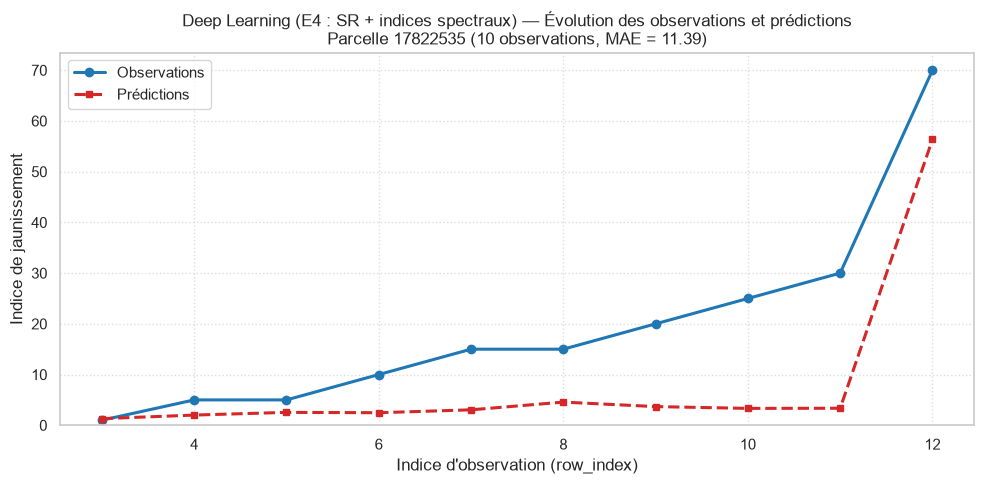

Parcelle sélectionnée pour le DL : 17822535


KeyError: 'id_plot'

In [41]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DL_VALIDATION_PREDICTIONS = (
    Path(r"C:\Users\ahtrabelsi\Desktop\stage\s2-super-resolution")
    / "outputs"
    / "DL_training_results"
    / "E4"
    / "predictions_val.csv"
)

# Remplacer ce chemin par le fichier de prédictions de validation du meilleur modèle ML.
# Le fichier doit contenir au minimum les colonnes :
# id_plot, row_index, y_true, y_pred
ML_VALIDATION_PREDICTIONS = Path(
    r"C:\Users\ahtrabelsi\Desktop\stage\s2-super-resolution\outputs\ML_regression\oof_predictions.csv"
)

PARCEL_PLOTS_OUTPUT_DIR = (
    Path(r"C:\Users\ahtrabelsi\Desktop\stage\s2-super-resolution")
    / "outputs"
    / "DL_training_results"
    / "plots"
)
PARCEL_PLOTS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def get_parcel_with_maximum_observations(predictions_path: Path) -> tuple[pd.DataFrame, str]:
    """Charge les prédictions et retourne la parcelle ayant le plus d'observations."""
    df = pd.read_csv(predictions_path)

    required_columns = {"id_plot", "row_index", "y_true", "y_pred"}
    missing_columns = required_columns - set(df.columns)
    if missing_columns:
        raise ValueError(
            f"Colonnes absentes dans {predictions_path.name}: {sorted(missing_columns)}"
        )

    counts = df.groupby("id_plot").size()
    selected_parcel = str(counts.idxmax())

    parcel_df = (
        df[df["id_plot"].astype(str) == selected_parcel]
        .sort_values("row_index")
        .copy()
    )

    return parcel_df, selected_parcel


def plot_observed_vs_predicted_evolution(
    predictions_path: Path,
    method_name: str,
    output_path: Path,
    selected_parcel: str | None = None,
) -> str:
    """
    Trace séparément l'évolution des valeurs observées et prédites
    pour la parcelle ayant le plus d'observations, ou pour une parcelle imposée.
    """
    df = pd.read_csv(predictions_path)

    if selected_parcel is None:
        parcel_df, selected_parcel = get_parcel_with_maximum_observations(predictions_path)
    else:
        parcel_df = (
            df[df["id_plot"].astype(str) == str(selected_parcel)]
            .sort_values("row_index")
            .copy()
        )

        if parcel_df.empty:
            raise ValueError(
                f"La parcelle {selected_parcel} est absente de {predictions_path}."
            )

    mae = (parcel_df["y_true"] - parcel_df["y_pred"]).abs().mean()

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(
        parcel_df["row_index"],
        parcel_df["y_true"],
        marker="o",
        linewidth=2.2,
        markersize=6,
        color="#1f77b4",
        label="Observations",
    )
    ax.plot(
        parcel_df["row_index"],
        parcel_df["y_pred"],
        marker="s",
        linewidth=2.2,
        markersize=5,
        linestyle="--",
        color="#d62728",
        label="Prédictions",
    )

    ax.set_title(
        f"{method_name} — Évolution des observations et prédictions\n"
        f"Parcelle {selected_parcel} ({len(parcel_df)} observations, MAE = {mae:.2f})"
    )
    ax.set_xlabel("Indice d'observation (row_index)")
    ax.set_ylabel("Indice de jaunissement")
    ax.set_ylim(bottom=0)
    ax.grid(True, linestyle=":", alpha=0.65)
    ax.legend(frameon=True)

    fig.tight_layout()
    fig.savefig(output_path, format="pdf", bbox_inches="tight")
    fig.savefig(output_path.with_suffix(".png"), dpi=300, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    return selected_parcel


# DL : modèle final retenu, E4 (SR + paper_indices).
dl_parcel = plot_observed_vs_predicted_evolution(
    predictions_path=DL_VALIDATION_PREDICTIONS,
    method_name="Deep Learning (E4 : SR + indices spectraux)",
    output_path=PARCEL_PLOTS_OUTPUT_DIR / "DL_E4_validation_parcel_evolution.pdf",
)

print(f"Parcelle sélectionnée pour le DL : {dl_parcel}")

# ML : graphique distinct.
# La même parcelle est imposée afin de comparer l'évolution sur une unité identique.
if ML_VALIDATION_PREDICTIONS.exists():
    plot_observed_vs_predicted_evolution(
        predictions_path=ML_VALIDATION_PREDICTIONS,
        method_name="Machine Learning",
        output_path=PARCEL_PLOTS_OUTPUT_DIR / "ML_validation_parcel_evolution.pdf",
        selected_parcel=dl_parcel,
    )
else:
    print(
        "Le fichier de prédictions ML est introuvable. "
        "Renseigner ML_VALIDATION_PREDICTIONS pour produire le graphique ML."
    )

Meilleure configuration ML sélectionnée : SR - BayesianRidge


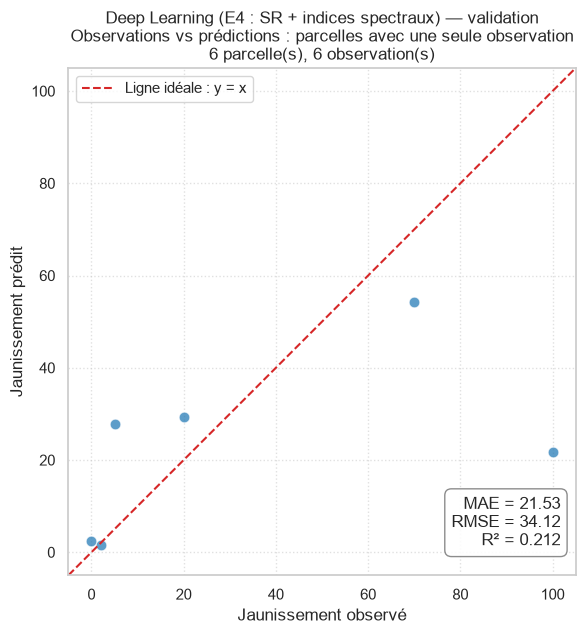

Figure enregistrée : C:\Users\ahtrabelsi\Desktop\stage\s2-super-resolution\outputs\comparison_plots\DL_E4_validation_single_observation_parcels.pdf


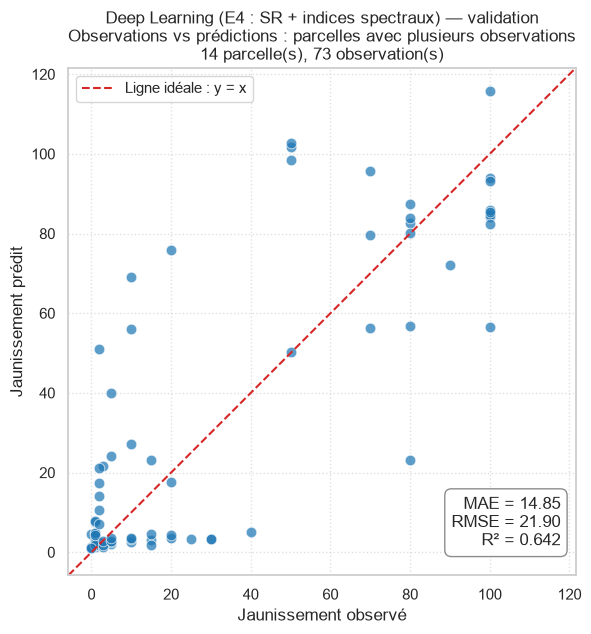

Figure enregistrée : C:\Users\ahtrabelsi\Desktop\stage\s2-super-resolution\outputs\comparison_plots\DL_E4_validation_multiple_observation_parcels.pdf


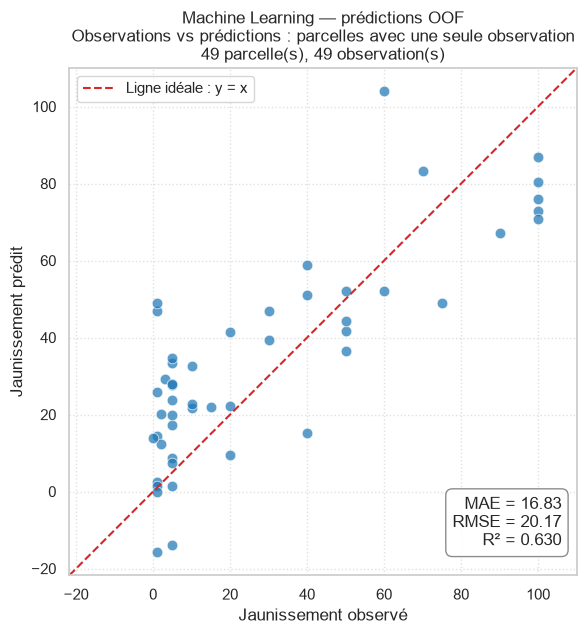

Figure enregistrée : C:\Users\ahtrabelsi\Desktop\stage\s2-super-resolution\outputs\comparison_plots\ML_OOF_single_observation_parcels.pdf


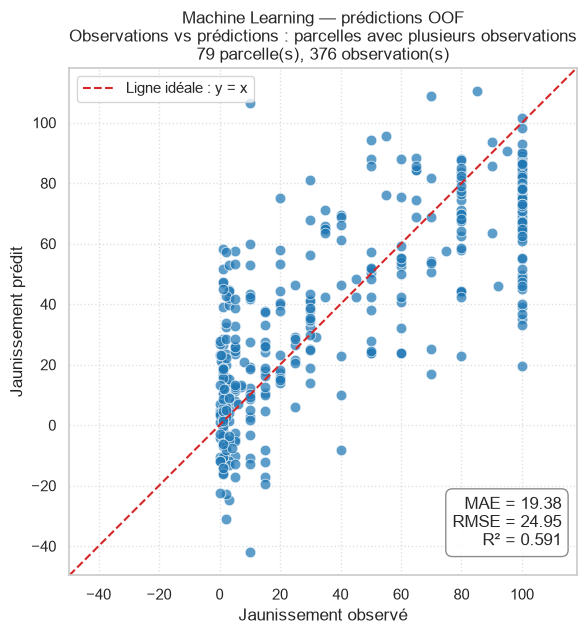

Figure enregistrée : C:\Users\ahtrabelsi\Desktop\stage\s2-super-resolution\outputs\comparison_plots\ML_OOF_multiple_observation_parcels.pdf

Figures enregistrées dans : C:\Users\ahtrabelsi\Desktop\stage\s2-super-resolution\outputs\comparison_plots


In [42]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

REPO_ROOT = Path(r"C:\Users\ahtrabelsi\Desktop\stage\s2-super-resolution")

DL_PREDICTIONS_PATH = (
    REPO_ROOT
    / "outputs"
    / "DL_training_results"
    / "E4"
    / "predictions_val.csv"
)

ML_PREDICTIONS_PATH = (
    REPO_ROOT
    / "outputs"
    / "ML_regression"
    / "oof_predictions.csv"
)

OUTPUT_DIR = (
    REPO_ROOT
    / "outputs"
    / "comparison_plots"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def add_ml_parcel_ids(ml_predictions: pd.DataFrame, source_df: pd.DataFrame) -> pd.DataFrame:
    """
    Ajoute id_plot aux prédictions OOF ML à partir de Original_Index.

    Le fichier OOF ML contient Original_Index, mais pas id_plot. La correspondance
    est reconstruite avec le DataFrame df utilisé pour l'entraînement ML.
    """
    if "Original_Index" not in ml_predictions.columns:
        raise ValueError(
            "La colonne 'Original_Index' est absente du fichier de prédictions ML."
        )

    if "id_plot" not in source_df.columns:
        raise ValueError("La colonne 'id_plot' est absente du DataFrame ML 'df'.")

    parcel_lookup = (
        source_df[["id_plot"]]
        .copy()
        .reset_index()
        .rename(columns={"index": "Original_Index"})
    )

    parcel_lookup["Original_Index"] = pd.to_numeric(
        parcel_lookup["Original_Index"],
        errors="coerce",
    )
    ml_predictions["Original_Index"] = pd.to_numeric(
        ml_predictions["Original_Index"],
        errors="coerce",
    )

    ml_predictions = ml_predictions.merge(
        parcel_lookup,
        on="Original_Index",
        how="left",
        validate="many_to_one",
    )

    if ml_predictions["id_plot"].isna().any():
        missing = int(ml_predictions["id_plot"].isna().sum())
        raise ValueError(
            f"{missing} prédictions ML ne peuvent pas être associées à une parcelle."
        )

    return ml_predictions


def select_best_ml_configuration(ml_predictions: pd.DataFrame) -> pd.DataFrame:
    """
    Sélectionne les prédictions du meilleur modèle ML.

    La sélection utilise overall_performance_df s'il est présent : priorité au
    RMSE OOF minimal, puis à la MAE minimale et au R² maximal.
    """
    if {"Feature_Group", "Model"}.issubset(ml_predictions.columns):
        if "overall_performance_df" in globals():
            best_ml_row = (
                overall_performance_df
                .sort_values(
                    ["OOF_RMSE", "OOF_MAE", "OOF_R2"],
                    ascending=[True, True, False],
                )
                .iloc[0]
            )

            best_feature_group = best_ml_row["Feature_Group"]
            best_model = best_ml_row["Model"]

            filtered = ml_predictions[
                (ml_predictions["Feature_Group"] == best_feature_group)
                & (ml_predictions["Model"] == best_model)
            ].copy()

            print(
                "Meilleure configuration ML sélectionnée : "
                f"{best_feature_group} - {best_model}"
            )
            return filtered

        unique_configs = ml_predictions[["Feature_Group", "Model"]].drop_duplicates()

        if len(unique_configs) == 1:
            return ml_predictions.copy()

        raise ValueError(
            "Plusieurs modèles ML sont présents dans le fichier OOF. "
            "Exécuter la cellule qui crée 'overall_performance_df' avant celle-ci."
        )

    return ml_predictions.copy()


def rescale_if_normalized(predictions: pd.DataFrame) -> pd.DataFrame:
    """
    Ramène les prédictions ML sur l'échelle 0-100 si y_true et y_pred sont
    stockés dans l'échelle normalisée 0-1.
    """
    predictions = predictions.copy()

    y_true_max = predictions["y_true"].abs().max()
    y_pred_max = predictions["y_pred"].abs().max()

    if y_true_max <= 1.5 and y_pred_max <= 1.5:
        predictions["y_true"] *= 100.0
        predictions["y_pred"] *= 100.0
        print("Prédictions ML converties de l'échelle [0, 1] vers [0, 100].")

    return predictions


def plot_observed_vs_predicted_by_parcel_type(
    predictions: pd.DataFrame,
    method_name: str,
    parcel_type: str,
    output_file_name: str,
) -> None:
    """
    Produit un nuage observé vs prédit pour :
    - les parcelles avec une seule observation ;
    - ou les parcelles avec plusieurs observations.
    """
    required_columns = {"id_plot", "y_true", "y_pred"}
    missing_columns = required_columns - set(predictions.columns)

    if missing_columns:
        raise ValueError(
            f"Colonnes manquantes pour {method_name}: {sorted(missing_columns)}"
        )

    predictions = predictions.copy()
    predictions["id_plot"] = predictions["id_plot"].astype(str)

    observations_per_parcel = predictions.groupby("id_plot").size()

    if parcel_type == "single":
        selected_parcels = observations_per_parcel[
            observations_per_parcel == 1
        ].index
        parcel_label = "parcelles avec une seule observation"
    elif parcel_type == "multiple":
        selected_parcels = observations_per_parcel[
            observations_per_parcel > 1
        ].index
        parcel_label = "parcelles avec plusieurs observations"
    else:
        raise ValueError("parcel_type doit être 'single' ou 'multiple'.")

    plot_data = predictions[
        predictions["id_plot"].isin(selected_parcels)
    ].copy()

    if plot_data.empty:
        print(f"Aucune donnée disponible : {method_name} — {parcel_label}.")
        return

    y_true = plot_data["y_true"].to_numpy(dtype=float)
    y_pred = plot_data["y_pred"].to_numpy(dtype=float)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred) if len(plot_data) > 1 else np.nan

    lower_limit = min(y_true.min(), y_pred.min())
    upper_limit = max(y_true.max(), y_pred.max())
    margin = max((upper_limit - lower_limit) * 0.05, 1.0)

    fig, ax = plt.subplots(figsize=(7.5, 6.5))

    ax.scatter(
        y_true,
        y_pred,
        s=58,
        alpha=0.72,
        color="#1f77b4",
        edgecolor="white",
        linewidth=0.6,
    )

    ax.plot(
        [lower_limit - margin, upper_limit + margin],
        [lower_limit - margin, upper_limit + margin],
        "--",
        color="#d62728",
        linewidth=1.5,
        label="Ligne idéale : y = x",
    )

    ax.set_xlim(lower_limit - margin, upper_limit + margin)
    ax.set_ylim(lower_limit - margin, upper_limit + margin)
    ax.set_aspect("equal", adjustable="box")

    ax.set_title(
        f"{method_name}\n"
        f"Observations vs prédictions : {parcel_label}\n"
        f"{len(selected_parcels)} parcelle(s), {len(plot_data)} observation(s)"
    )
    ax.set_xlabel("Jaunissement observé")
    ax.set_ylabel("Jaunissement prédit")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(loc="upper left")

    metrics_text = (
        f"MAE = {mae:.2f}\n"
        f"RMSE = {rmse:.2f}\n"
        f"R² = {r2:.3f}"
    )
    ax.text(
        0.97,
        0.05,
        metrics_text,
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        bbox={
            "boxstyle": "round,pad=0.4",
            "facecolor": "white",
            "edgecolor": "gray",
            "alpha": 0.9,
        },
    )

    fig.tight_layout()

    pdf_path = OUTPUT_DIR / f"{output_file_name}.pdf"
    png_path = OUTPUT_DIR / f"{output_file_name}.png"

    fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
    fig.savefig(png_path, dpi=300, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    print(f"Figure enregistrée : {pdf_path}")


# ------------------------------------------------------------------
# 1. Chargement des prédictions DL : expérience E4, ensemble validation
# ------------------------------------------------------------------
dl_predictions = pd.read_csv(DL_PREDICTIONS_PATH)

# ------------------------------------------------------------------
# 2. Chargement des prédictions ML OOF et ajout des identifiants de parcelles
# ------------------------------------------------------------------
ml_predictions = pd.read_csv(ML_PREDICTIONS_PATH)

# Élimine une éventuelle colonne index ajoutée par to_csv(index=True).
ml_predictions = ml_predictions.loc[
    :,
    ~ml_predictions.columns.str.contains(r"^Unnamed")
].copy()

ml_predictions = add_ml_parcel_ids(ml_predictions, df)
ml_predictions = select_best_ml_configuration(ml_predictions)
ml_predictions = rescale_if_normalized(ml_predictions)

# ------------------------------------------------------------------
# 3. Graphiques DL : une observation et plusieurs observations
# ------------------------------------------------------------------
plot_observed_vs_predicted_by_parcel_type(
    predictions=dl_predictions,
    method_name="Deep Learning (E4 : SR + indices spectraux) — validation",
    parcel_type="single",
    output_file_name="DL_E4_validation_single_observation_parcels",
)

plot_observed_vs_predicted_by_parcel_type(
    predictions=dl_predictions,
    method_name="Deep Learning (E4 : SR + indices spectraux) — validation",
    parcel_type="multiple",
    output_file_name="DL_E4_validation_multiple_observation_parcels",
)

# ------------------------------------------------------------------
# 4. Graphiques ML : une observation et plusieurs observations
# ------------------------------------------------------------------
plot_observed_vs_predicted_by_parcel_type(
    predictions=ml_predictions,
    method_name="Machine Learning — prédictions OOF",
    parcel_type="single",
    output_file_name="ML_OOF_single_observation_parcels",
)

plot_observed_vs_predicted_by_parcel_type(
    predictions=ml_predictions,
    method_name="Machine Learning — prédictions OOF",
    parcel_type="multiple",
    output_file_name="ML_OOF_multiple_observation_parcels",
)

print(f"\nFigures enregistrées dans : {OUTPUT_DIR}")

Best ML configuration: SR - BayesianRidge
DL multiple-observation parcels: 14
ML multiple-observation parcels: 79


,id_plot,n_observations,MAE,RMSE,Bias_observed_minus_predicted,Mean_observed,Mean_predicted,R2
7,17822535,10,11.39,13.98,11.33,19.600000,8.267804,0.455
5,16473998,9,20.61,30.70,-19.11,26.555556,45.666056,-0.384
4,16468872,9,19.84,30.52,-19.84,3.000000,22.841869,-63.480
12,9313219,9,10.80,12.66,4.40,69.555556,65.159586,0.866
8,17824054,8,10.29,11.89,-8.63,3.750000,12.380504,-9.514
11,8062939,5,13.07,15.83,12.74,47.200000,34.459921,0.845
10,18440749,5,8.34,11.31,-8.34,47.200000,55.541296,0.918
1,117191,4,24.24,30.55,-8.08,55.500000,63.575289,0.538
6,16579421,3,32.10,38.57,29.02,40.000000,10.978241,-0.395
2,13903914,3,4.77,5.65,-0.56,30.666667,31.226957,0.974


,id_plot,n_observations,MAE,RMSE,Bias_observed_minus_predicted,Mean_observed,Mean_predicted,R2
2,11130978,14,36.88,39.02,35.36,87.285714,51.925472,-1.022
70,8072227,14,25.47,27.20,22.53,85.750000,63.221704,0.141
71,8094233,13,20.96,23.55,-20.96,28.230769,49.189427,-2.860
62,18759775,12,22.03,25.96,22.03,81.666667,59.635175,0.285
43,16578178,11,13.34,17.32,-6.98,24.181818,31.162305,0.577
59,18439333,11,12.43,14.33,-5.62,63.636364,69.260421,0.601
48,17620773,11,9.37,12.23,0.18,59.181818,58.997836,0.871
67,8053190,10,26.49,29.94,22.29,88.500000,66.212945,-0.106
11,13538354,10,23.95,27.75,21.99,77.100000,55.105358,0.449
51,17822535,10,15.70,18.90,13.98,19.600000,5.616085,0.003


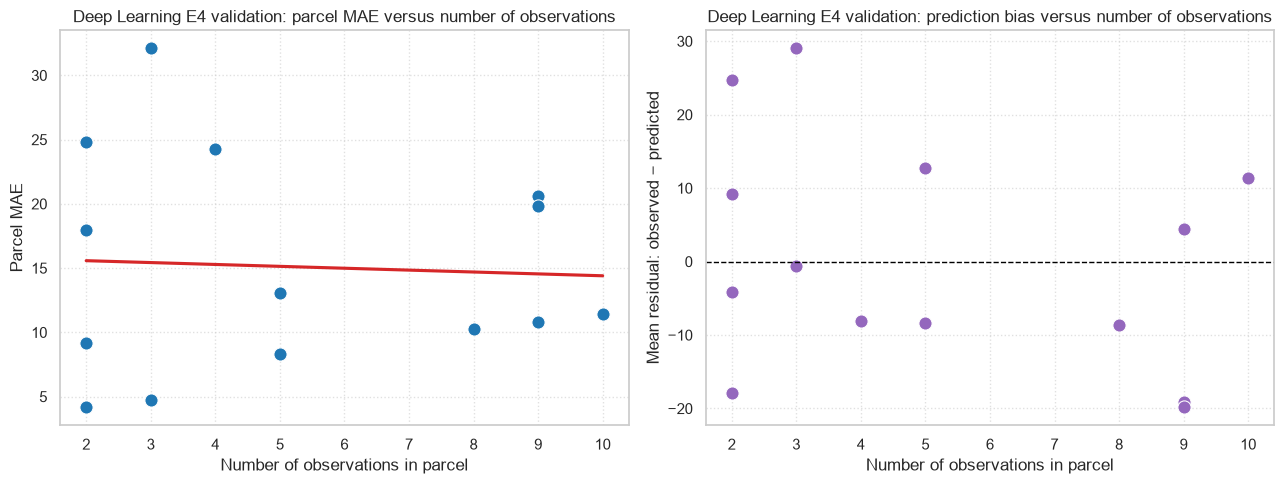

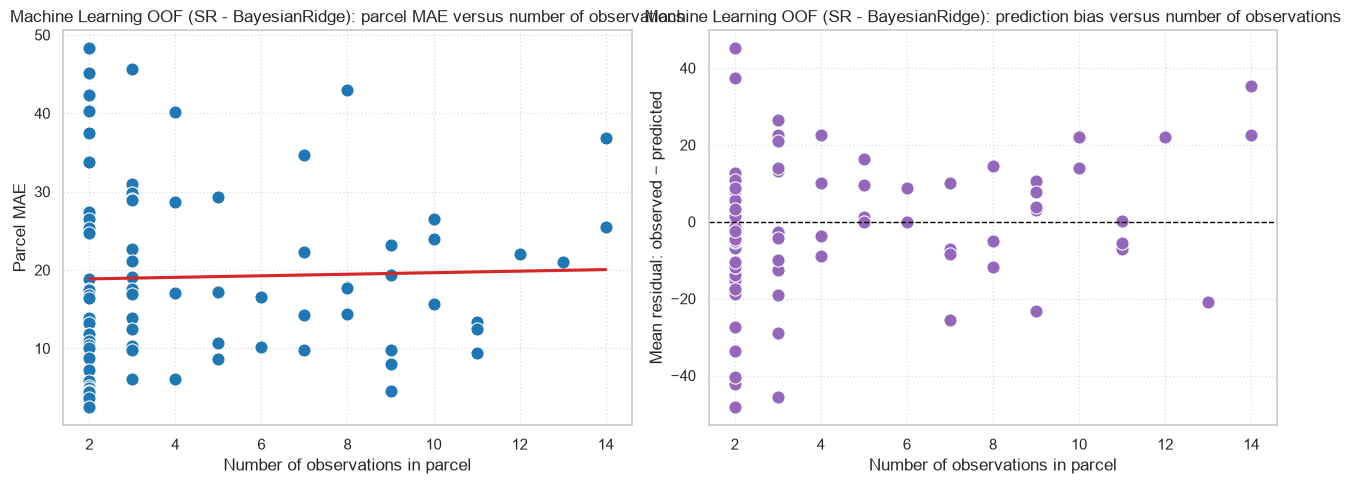

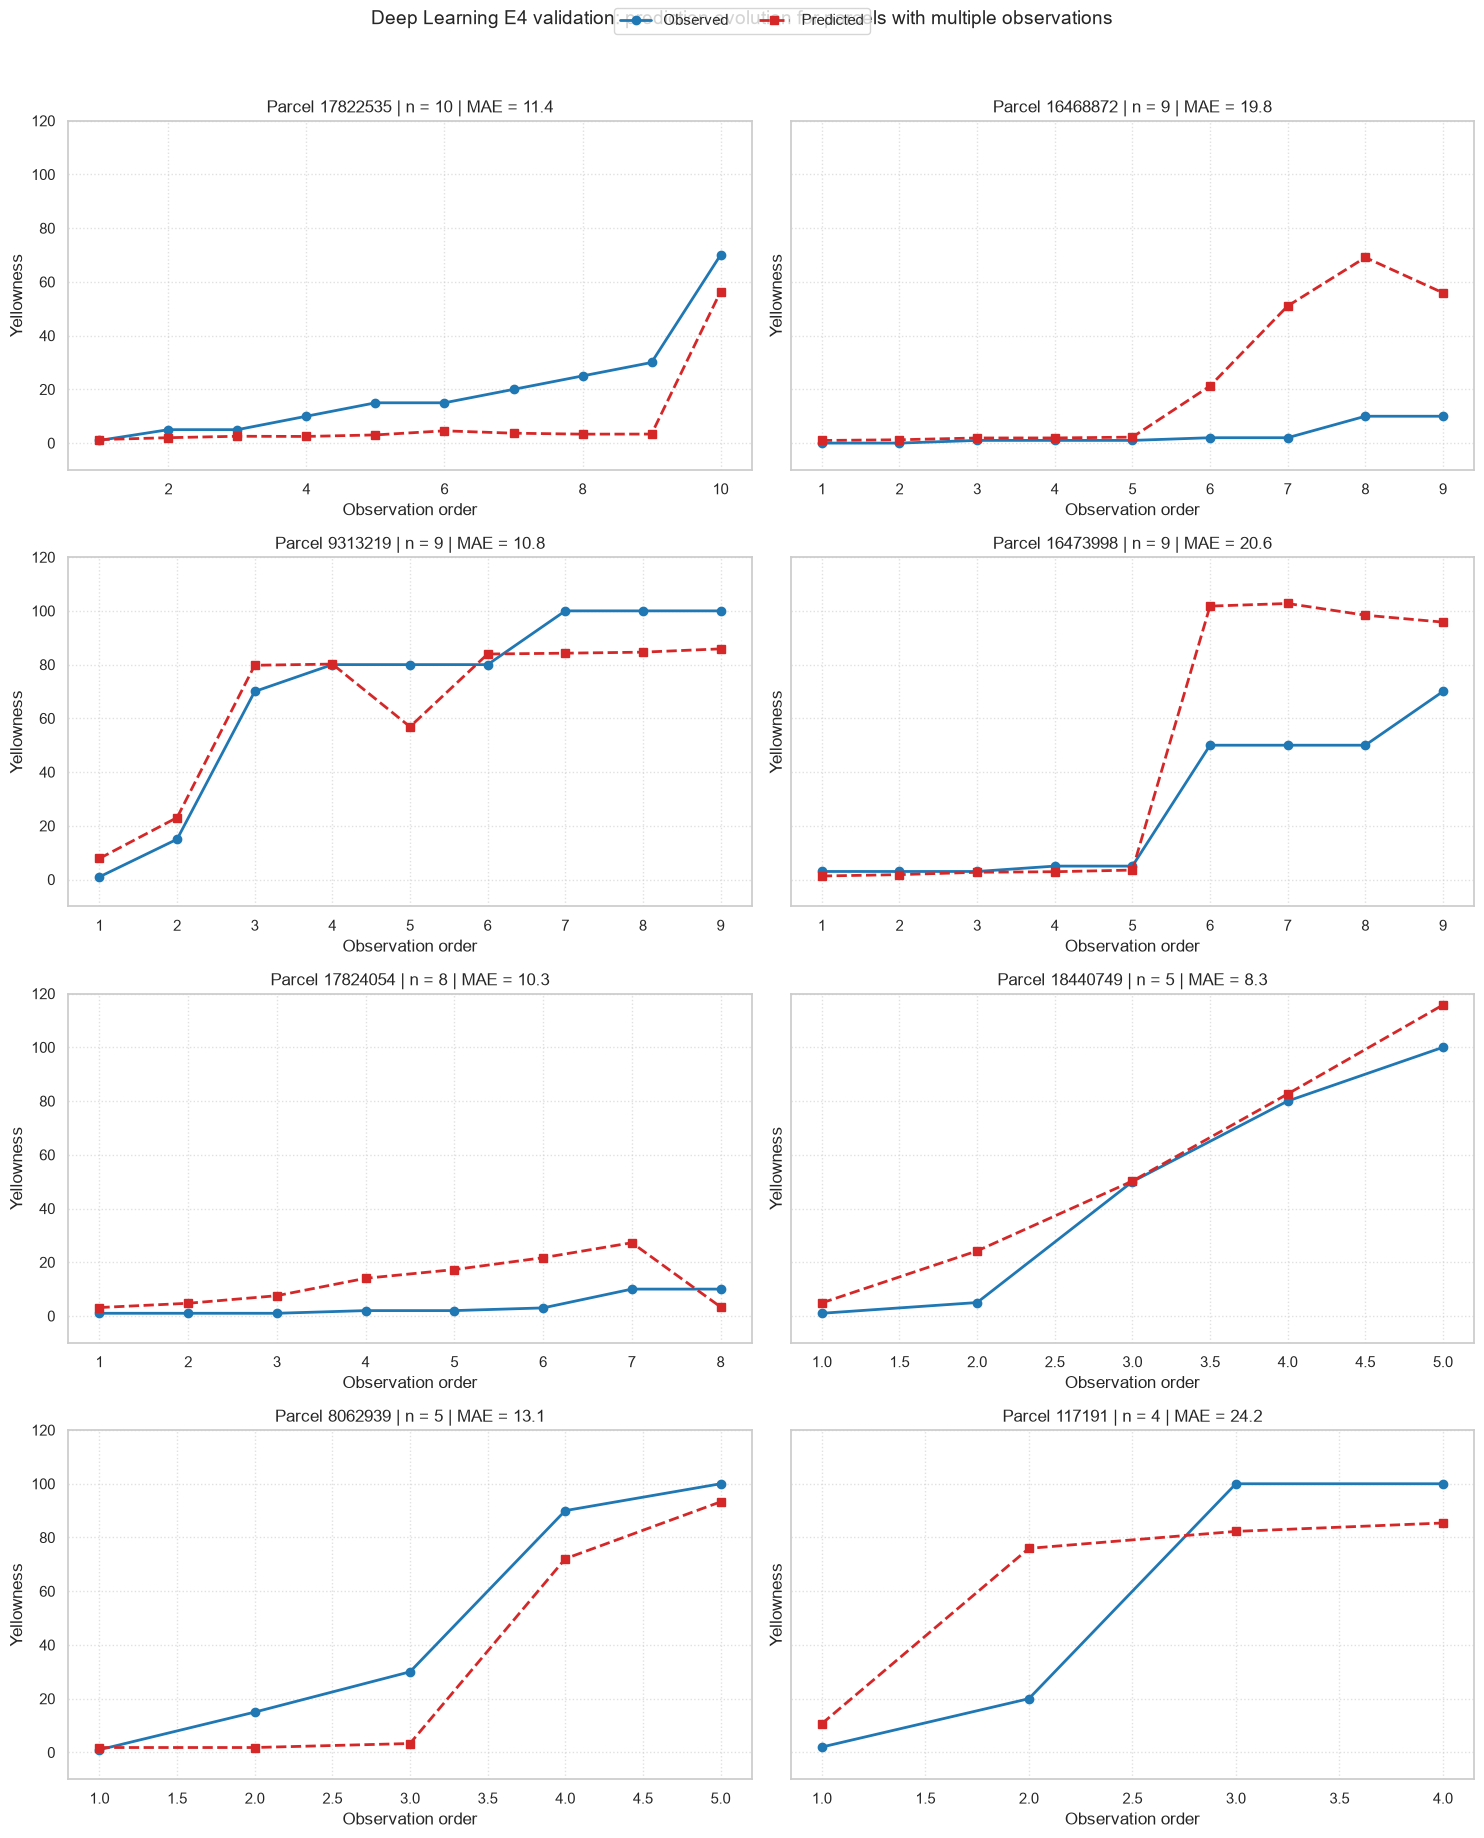

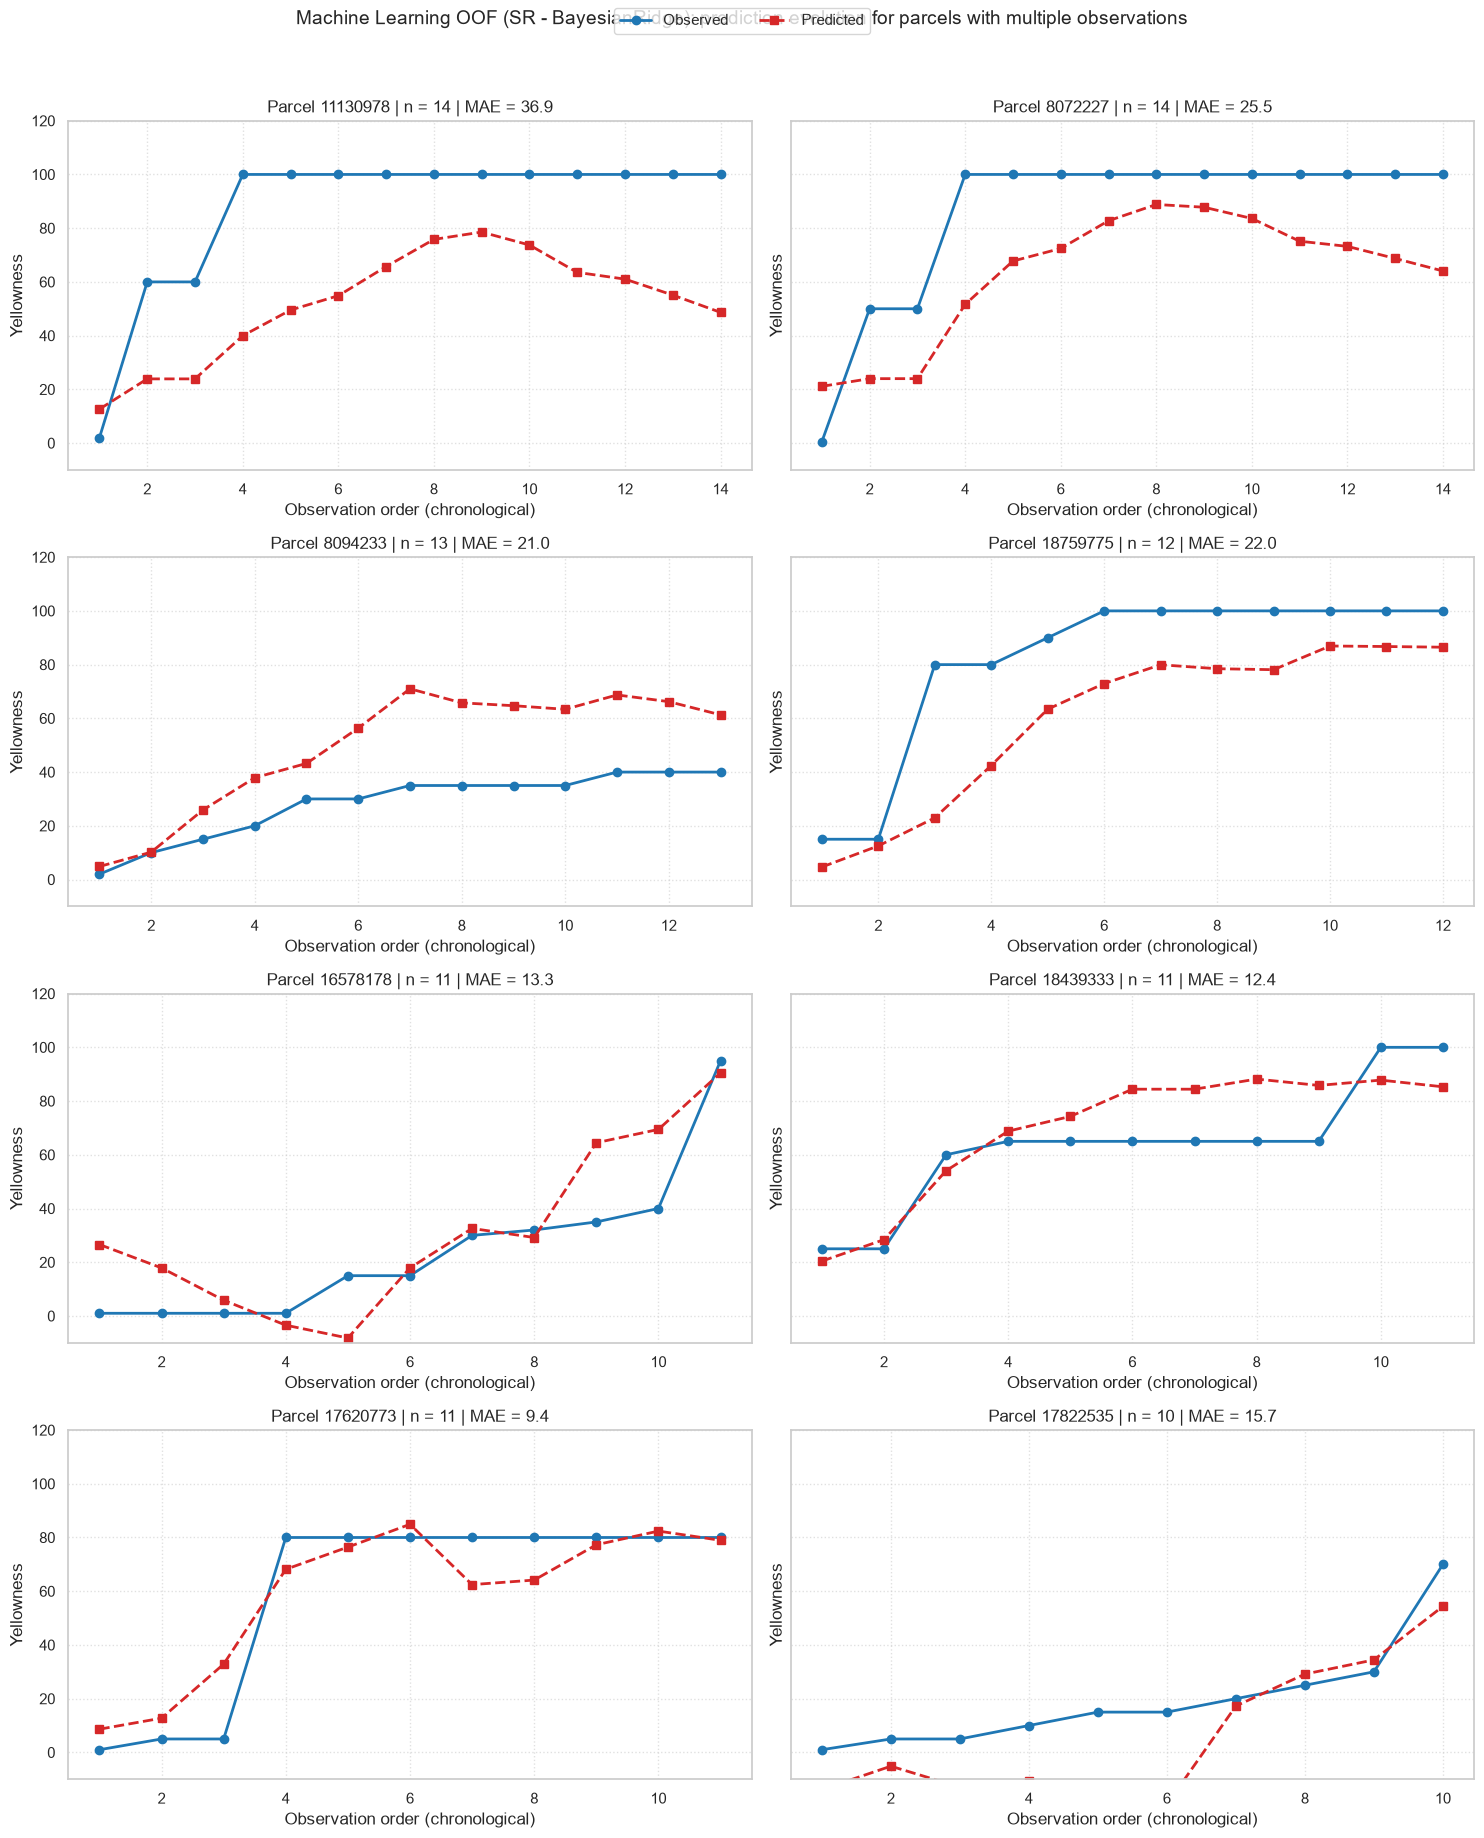

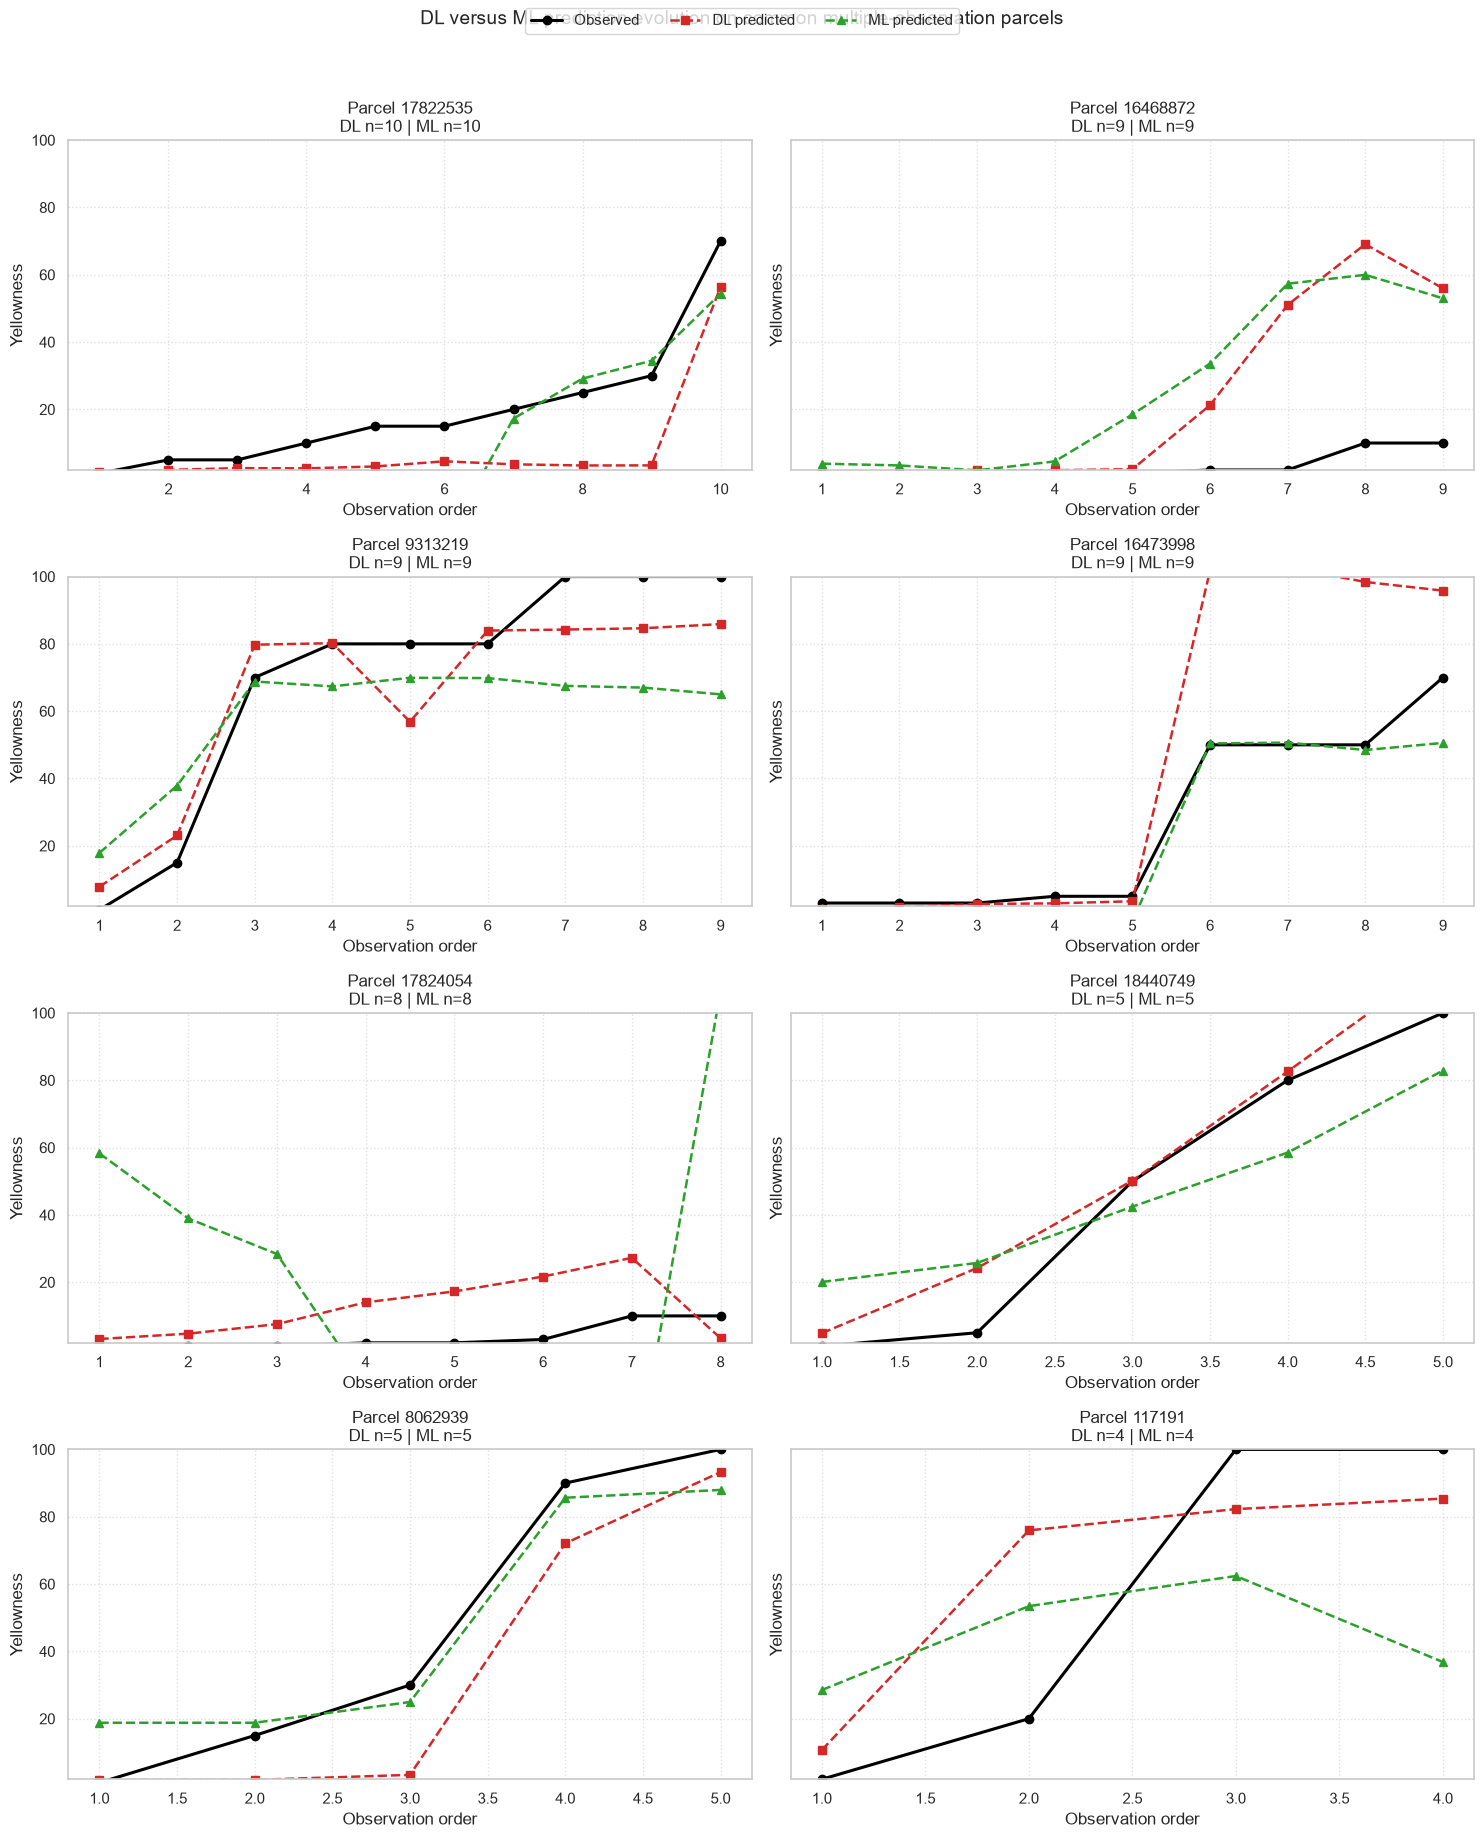

Common multiple-observation parcels: 14

All figures were saved to:
C:\Users\ahtrabelsi\Desktop\stage\s2-super-resolution\outputs\multiple_observation_analysis


In [47]:
# Analysis of prediction behaviour for parcels with multiple observations:
# ML (OOF predictions) versus DL (E4 validation predictions).

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------
REPO_ROOT = Path(r"C:\Users\ahtrabelsi\Desktop\stage\s2-super-resolution")

DL_PATH = (
    REPO_ROOT
    / "outputs"
    / "DL_training_results"
    / "E4"
    / "predictions_val.csv"
)

ML_PATH = (
    REPO_ROOT
    / "outputs"
    / "ML_regression"
    / "oof_predictions.csv"
)

MULTI_OBS_OUTPUT_DIR = (
    REPO_ROOT
    / "outputs"
    / "multiple_observation_analysis"
)
MULTI_OBS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

N_PARCELS_TO_PLOT = 8


# ---------------------------------------------------------------------
# Utility functions
# ---------------------------------------------------------------------
def add_id_plot_and_date_to_ml_predictions(
    predictions: pd.DataFrame,
    source_dataframe: pd.DataFrame,
) -> pd.DataFrame:
    """
    Recovers id_plot and observation date from Original_Index.

    Original_Index was created from df during GroupKFold preparation.
    """
    predictions = predictions.copy()

    if "Original_Index" not in predictions.columns:
        raise ValueError("ML predictions must contain the 'Original_Index' column.")

    if "id_plot" not in source_dataframe.columns:
        raise ValueError("The source DataFrame 'df' must contain 'id_plot'.")

    lookup_columns = ["id_plot"]

    available_date_column = next(
        (
            column
            for column in [
                "observation_date",
                "s2_acquisition_date",
                "s2_date",
            ]
            if column in source_dataframe.columns
        ),
        None,
    )

    if available_date_column is not None:
        lookup_columns.append(available_date_column)

    lookup = (
        source_dataframe[lookup_columns]
        .copy()
        .reset_index()
        .rename(columns={"index": "Original_Index"})
    )

    predictions["Original_Index"] = pd.to_numeric(
        predictions["Original_Index"],
        errors="coerce",
    )
    lookup["Original_Index"] = pd.to_numeric(
        lookup["Original_Index"],
        errors="coerce",
    )

    predictions = predictions.merge(
        lookup,
        on="Original_Index",
        how="left",
        validate="many_to_one",
    )

    if predictions["id_plot"].isna().any():
        n_missing = int(predictions["id_plot"].isna().sum())
        raise ValueError(
            f"Could not associate {n_missing} ML prediction(s) with an id_plot."
        )

    if available_date_column is not None:
        predictions = predictions.rename(
            columns={available_date_column: "observation_date"}
        )
        predictions["observation_date"] = pd.to_datetime(
            predictions["observation_date"],
            errors="coerce",
        )

    return predictions


def select_best_ml_predictions(predictions: pd.DataFrame) -> tuple[pd.DataFrame, str]:
    """
    Filters OOF predictions to the best ML Feature_Group / Model combination.

    Ranking criterion:
    1. Lowest OOF RMSE
    2. Lowest OOF MAE
    3. Highest OOF R²
    """
    predictions = predictions.copy()

    if not {"Feature_Group", "Model"}.issubset(predictions.columns):
        return predictions, "ML"

    if "overall_performance_df" not in globals():
        unique_configs = predictions[["Feature_Group", "Model"]].drop_duplicates()

        if len(unique_configs) != 1:
            raise ValueError(
                "Run the GroupKFold cell first so that overall_performance_df is available."
            )

        config = unique_configs.iloc[0]
        return predictions, f"{config['Feature_Group']} - {config['Model']}"

    best_row = (
        overall_performance_df
        .sort_values(
            ["OOF_RMSE", "OOF_MAE", "OOF_R2"],
            ascending=[True, True, False],
        )
        .iloc[0]
    )

    best_group = best_row["Feature_Group"]
    best_model = best_row["Model"]

    filtered_predictions = predictions[
        (predictions["Feature_Group"] == best_group)
        & (predictions["Model"] == best_model)
    ].copy()

    return filtered_predictions, f"{best_group} - {best_model}"


def convert_to_percentage_if_needed(predictions: pd.DataFrame) -> pd.DataFrame:
    """Converts normalized [0, 1] predictions back to the [0, 100] scale."""
    predictions = predictions.copy()

    max_true = predictions["y_true"].abs().max()
    max_pred = predictions["y_pred"].abs().max()

    if max_true <= 1.5 and max_pred <= 1.5:
        predictions["y_true"] = predictions["y_true"] * 100.0
        predictions["y_pred"] = predictions["y_pred"] * 100.0

    return predictions


def prepare_multiple_observation_parcels(
    predictions: pd.DataFrame,
    method_name: str,
) -> pd.DataFrame:
    """Keeps parcels having at least two observations and adds residual fields."""
    required_columns = {"id_plot", "y_true", "y_pred"}
    missing_columns = required_columns - set(predictions.columns)

    if missing_columns:
        raise ValueError(
            f"{method_name}: missing required columns: {sorted(missing_columns)}"
        )

    prepared = predictions.copy()
    prepared["id_plot"] = prepared["id_plot"].astype(str)
    prepared["y_true"] = pd.to_numeric(prepared["y_true"], errors="coerce")
    prepared["y_pred"] = pd.to_numeric(prepared["y_pred"], errors="coerce")

    prepared = prepared.dropna(subset=["id_plot", "y_true", "y_pred"]).copy()

    parcel_counts = prepared.groupby("id_plot").size().rename("n_observations")
    prepared = prepared.merge(
        parcel_counts,
        left_on="id_plot",
        right_index=True,
        how="left",
    )

    prepared = prepared[prepared["n_observations"] > 1].copy()
    prepared["residual"] = prepared["y_true"] - prepared["y_pred"]
    prepared["absolute_error"] = prepared["residual"].abs()
    prepared["method"] = method_name

    if "observation_date" in prepared.columns:
        prepared["observation_date"] = pd.to_datetime(
            prepared["observation_date"],
            errors="coerce",
        )

    if "observation_date" in prepared.columns and prepared["observation_date"].notna().any():
        prepared = prepared.sort_values(
            ["id_plot", "observation_date", "Original_Index"]
            if "Original_Index" in prepared.columns
            else ["id_plot", "observation_date"]
        ).copy()
        prepared["observation_order"] = prepared.groupby("id_plot").cumcount() + 1
        prepared["x_axis_label"] = "Observation order (chronological)"
    else:
        ordering_column = "row_index" if "row_index" in prepared.columns else "Original_Index"

        if ordering_column not in prepared.columns:
            prepared[ordering_column] = prepared.groupby("id_plot").cumcount()

        prepared = prepared.sort_values(["id_plot", ordering_column]).copy()
        prepared["observation_order"] = prepared.groupby("id_plot").cumcount() + 1
        prepared["x_axis_label"] = "Observation order"

    return prepared


def calculate_per_parcel_metrics(predictions: pd.DataFrame) -> pd.DataFrame:
    """Calculates observed-versus-predicted metrics separately for each parcel."""
    rows = []

    for parcel_id, group in predictions.groupby("id_plot"):
        y_true = group["y_true"].to_numpy(dtype=float)
        y_pred = group["y_pred"].to_numpy(dtype=float)

        rows.append(
            {
                "id_plot": str(parcel_id),
                "n_observations": len(group),
                "MAE": mean_absolute_error(y_true, y_pred),
                "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
                "Bias_observed_minus_predicted": np.mean(y_true - y_pred),
                "Mean_observed": np.mean(y_true),
                "Mean_predicted": np.mean(y_pred),
                "R2": r2_score(y_true, y_pred) if len(group) >= 2 else np.nan,
            }
        )

    return pd.DataFrame(rows).sort_values(
        ["n_observations", "MAE"],
        ascending=[False, False],
    )


def plot_parcel_evolution_panels(
    predictions: pd.DataFrame,
    method_name: str,
    output_stem: str,
    n_parcels: int = 8,
) -> None:
    """
    Displays observed and predicted values through the observation sequence
    for the parcels containing the most observations.
    """
    selected_parcels = (
        predictions.groupby("id_plot")
        .size()
        .sort_values(ascending=False)
        .head(n_parcels)
        .index
        .tolist()
    )

    selected = predictions[predictions["id_plot"].isin(selected_parcels)].copy()

    n_columns = 2
    n_rows = int(np.ceil(len(selected_parcels) / n_columns))

    fig, axes = plt.subplots(
        n_rows,
        n_columns,
        figsize=(15, 4.5 * n_rows),
        sharey=True,
    )
    axes = np.atleast_1d(axes).ravel()

    for ax, parcel_id in zip(axes, selected_parcels):
        parcel = selected[selected["id_plot"] == parcel_id].sort_values(
            "observation_order"
        )

        parcel_mae = mean_absolute_error(parcel["y_true"], parcel["y_pred"])

        ax.plot(
            parcel["observation_order"],
            parcel["y_true"],
            marker="o",
            linewidth=2,
            color="#1f77b4",
            label="Observed",
        )
        ax.plot(
            parcel["observation_order"],
            parcel["y_pred"],
            marker="s",
            linewidth=2,
            linestyle="--",
            color="#d62728",
            label="Predicted",
        )

        ax.set_title(
            f"Parcel {parcel_id} | n = {len(parcel)} | MAE = {parcel_mae:.1f}"
        )
        ax.set_xlabel(parcel["x_axis_label"].iloc[0])
        ax.set_ylabel("Yellowness")
        ax.grid(True, linestyle=":", alpha=0.6)
        ax.set_ylim(
            predictions["y_true"].min()-10,
            predictions["y_true"].max()+20,
        )

    for ax in axes[len(selected_parcels):]:
        ax.set_axis_off()

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2, frameon=True)

    fig.suptitle(
        f"{method_name}: prediction evolution for parcels with multiple observations",
        y=1.02,
        fontsize=14,
    )
    fig.tight_layout()

    fig.savefig(
        MULTI_OBS_OUTPUT_DIR / f"{output_stem}_evolution_panels.png",
        dpi=300,
        bbox_inches="tight",
    )
    fig.savefig(
        MULTI_OBS_OUTPUT_DIR / f"{output_stem}_evolution_panels.pdf",
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)


def plot_observation_count_effect(
    parcel_metrics: pd.DataFrame,
    method_name: str,
    output_stem: str,
) -> None:
    """
    Shows whether parcels with more observations have lower or higher errors.
    Each dot corresponds to one parcel.
    """
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    sns.scatterplot(
        data=parcel_metrics,
        x="n_observations",
        y="MAE",
        s=90,
        color="#1f77b4",
        ax=axes[0],
    )
    sns.regplot(
        data=parcel_metrics,
        x="n_observations",
        y="MAE",
        scatter=False,
        ci=None,
        color="#d62728",
        ax=axes[0],
    )
    axes[0].set_title(f"{method_name}: parcel MAE versus number of observations")
    axes[0].set_xlabel("Number of observations in parcel")
    axes[0].set_ylabel("Parcel MAE")
    axes[0].grid(True, linestyle=":", alpha=0.6)

    sns.scatterplot(
        data=parcel_metrics,
        x="n_observations",
        y="Bias_observed_minus_predicted",
        s=90,
        color="#9467bd",
        ax=axes[1],
    )
    axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[1].set_title(f"{method_name}: prediction bias versus number of observations")
    axes[1].set_xlabel("Number of observations in parcel")
    axes[1].set_ylabel("Mean residual: observed − predicted")
    axes[1].grid(True, linestyle=":", alpha=0.6)

    fig.tight_layout()
    fig.savefig(
        MULTI_OBS_OUTPUT_DIR / f"{output_stem}_effect_of_observation_count.png",
        dpi=300,
        bbox_inches="tight",
    )
    fig.savefig(
        MULTI_OBS_OUTPUT_DIR / f"{output_stem}_effect_of_observation_count.pdf",
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)


# ---------------------------------------------------------------------
# 1. Load and prepare DL validation predictions
# ---------------------------------------------------------------------
dl_predictions_raw = pd.read_csv(DL_PATH)
dl_multiple = prepare_multiple_observation_parcels(
    predictions=dl_predictions_raw,
    method_name="DL E4 validation",
)

# ---------------------------------------------------------------------
# 2. Load and prepare ML OOF predictions
# ---------------------------------------------------------------------
ml_predictions_raw = pd.read_csv(ML_PATH)

# Removes the unnamed CSV index column resulting from to_csv(index=True).
ml_predictions_raw = ml_predictions_raw.loc[
    :,
    ~ml_predictions_raw.columns.str.contains(r"^Unnamed"),
].copy()

ml_predictions_raw = add_id_plot_and_date_to_ml_predictions(
    predictions=ml_predictions_raw,
    source_dataframe=df,
)

ml_predictions_best, best_ml_name = select_best_ml_predictions(ml_predictions_raw)
ml_predictions_best = convert_to_percentage_if_needed(ml_predictions_best)

ml_multiple = prepare_multiple_observation_parcels(
    predictions=ml_predictions_best,
    method_name=f"ML OOF ({best_ml_name})",
)

print(f"Best ML configuration: {best_ml_name}")
print(f"DL multiple-observation parcels: {dl_multiple['id_plot'].nunique()}")
print(f"ML multiple-observation parcels: {ml_multiple['id_plot'].nunique()}")


# ---------------------------------------------------------------------
# 3. Per-parcel metrics and observation-count diagnostics
# ---------------------------------------------------------------------
dl_parcel_metrics = calculate_per_parcel_metrics(dl_multiple)
ml_parcel_metrics = calculate_per_parcel_metrics(ml_multiple)

display(
    dl_parcel_metrics.head(10).style.format(
        {
            "MAE": "{:.2f}",
            "RMSE": "{:.2f}",
            "Bias_observed_minus_predicted": "{:.2f}",
            "R2": "{:.3f}",
        }
    ).set_caption("DL: parcels with multiple observations and largest MAE")
)

display(
    ml_parcel_metrics.head(10).style.format(
        {
            "MAE": "{:.2f}",
            "RMSE": "{:.2f}",
            "Bias_observed_minus_predicted": "{:.2f}",
            "R2": "{:.3f}",
        }
    ).set_caption("ML: parcels with multiple observations and largest MAE")
)

plot_observation_count_effect(
    parcel_metrics=dl_parcel_metrics,
    method_name="Deep Learning E4 validation",
    output_stem="DL_E4",
)

plot_observation_count_effect(
    parcel_metrics=ml_parcel_metrics,
    method_name=f"Machine Learning OOF ({best_ml_name})",
    output_stem="ML_OOF",
)


# ---------------------------------------------------------------------
# 4. Evolution plots: most observed parcels, one figure per strategy
# ---------------------------------------------------------------------
plot_parcel_evolution_panels(
    predictions=dl_multiple,
    method_name="Deep Learning E4 validation",
    output_stem="DL_E4",
    n_parcels=N_PARCELS_TO_PLOT,
)

plot_parcel_evolution_panels(
    predictions=ml_multiple,
    method_name=f"Machine Learning OOF ({best_ml_name})",
    output_stem="ML_OOF",
    n_parcels=N_PARCELS_TO_PLOT,
)


# ---------------------------------------------------------------------
# 5. Direct comparison on parcels available in BOTH DL validation and ML OOF
# ---------------------------------------------------------------------
common_parcels = sorted(
    set(dl_multiple["id_plot"]).intersection(set(ml_multiple["id_plot"]))
)

if common_parcels:
    common_counts = (
        dl_multiple[dl_multiple["id_plot"].isin(common_parcels)]
        .groupby("id_plot")
        .size()
        .sort_values(ascending=False)
    )

    parcels_to_compare = common_counts.head(N_PARCELS_TO_PLOT).index.tolist()

    n_columns = 2
    n_rows = int(np.ceil(len(parcels_to_compare) / n_columns))

    fig, axes = plt.subplots(
        n_rows,
        n_columns,
        figsize=(15, 4.5 * n_rows),
        sharey=True,
    )
    axes = np.atleast_1d(axes).ravel()

    for ax, parcel_id in zip(axes, parcels_to_compare):
        dl_parcel = dl_multiple[
            dl_multiple["id_plot"] == parcel_id
        ].sort_values("observation_order")

        ml_parcel = ml_multiple[
            ml_multiple["id_plot"] == parcel_id
        ].sort_values("observation_order")

        # Observed values are plotted once from DL.
        ax.plot(
            dl_parcel["observation_order"],
            dl_parcel["y_true"],
            marker="o",
            linewidth=2.2,
            color="black",
            label="Observed",
        )

        ax.plot(
            dl_parcel["observation_order"],
            dl_parcel["y_pred"],
            marker="s",
            linestyle="--",
            linewidth=1.8,
            color="#d62728",
            label="DL predicted",
        )

        ax.plot(
            ml_parcel["observation_order"],
            ml_parcel["y_pred"],
            marker="^",
            linestyle="--",
            linewidth=1.8,
            color="#2ca02c",
            label="ML predicted",
        )

        ax.set_title(
            f"Parcel {parcel_id}\n"
            f"DL n={len(dl_parcel)} | ML n={len(ml_parcel)}"
        )
        ax.set_xlabel("Observation order")
        ax.set_ylabel("Yellowness")
        ax.set_ylim(
            min(dl_parcel["y_true"].min(), ml_parcel["y_true"].min()),
            max(dl_parcel["y_true"].max(), ml_parcel["y_true"].max()),
        )
        ax.grid(True, linestyle=":", alpha=0.6)

    for ax in axes[len(parcels_to_compare):]:
        ax.set_axis_off()

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=3, frameon=True)

    fig.suptitle(
        "DL versus ML prediction evolution on common multiple-observation parcels",
        y=1.02,
        fontsize=14,
    )
    fig.tight_layout()

    fig.savefig(
        MULTI_OBS_OUTPUT_DIR / "DL_vs_ML_common_parcels_evolution.png",
        dpi=300,
        bbox_inches="tight",
    )
    fig.savefig(
        MULTI_OBS_OUTPUT_DIR / "DL_vs_ML_common_parcels_evolution.pdf",
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    print(f"Common multiple-observation parcels: {len(common_parcels)}")
else:
    print(
        "No parcel with multiple observations is shared between the DL validation "
        "predictions and the ML OOF predictions."
    )

print(f"\nAll figures were saved to:\n{MULTI_OBS_OUTPUT_DIR}")

In [34]:
oof_plot_df.to_csv(r"C:\Users\ahtrabelsi\Desktop\stage\s2-super-resolution\outputs\ML_regression\oof_predictions.csv")